# 01_EDA — 법인카드 사용 패턴 전수 탐색

**목적:** L1(36개월 완전관측 법인 3,372개) 전수 EDA — 데이터 품질 검증 → 구조 발견 → 분석 모집단 필터링 체인(L0→L3) 정당화 → 이상 월 탐지 → 카드 심층·시계열 → 브리지(주제 확정 근거).

**입력:** `data/raw/데이터.parquet` (365,988행 × 70컬럼, 법인×월 패널, 202301~202512)

**출력:** `outputs/figures/01_*.png`, `outputs/tables/01_*.csv`, `data/processed/L3_법인목록.parquet`

**핵심 설계 반영 사항(§5, 2026-07-16 팀 합의):** L3(핵심 모델링 군)는 **Train 기준월 구간(202304~202403)의 총 신용카드사용금액 상위 10%**로 선정한다. 36개월 전체 총액 기준은 Holdout(Valid/Test) 기간 정보가 모집단 선정에 유입되는 누수이므로 금지.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import common
from common import (IM, LABEL_COLOR, SERIES, SEED, ID, YM, CARD,
                    set_korean_font, load_data, filtering_chain, save_fig,
                    TRAIN_T_START, TRAIN_T_END)

np.random.seed(SEED)
set_korean_font()
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

df = load_data()
print('원본 shape:', df.shape)

원본 shape: (365988, 70)


## 1. 데이터 품질 — 규모·결측·중복·dtype, 완전관측 L1 확정

In [2]:
n_dup = int(df.duplicated([ID, YM]).sum())
n_missing = int(df.isna().sum().sum())
print(f'행 × 열: {df.shape[0]:,} × {df.shape[1]}')
print(f'법인 수: {df[ID].nunique():,} / 기준년월: {df[YM].min()}~{df[YM].max()} ({df[YM].nunique()}개월)')
print(f'(법인ID, 기준년월) 중복: {n_dup}건 / 결측 총계: {n_missing}건')
assert n_dup == 0, '중복 키 존재 — 패널 구조 위반'
miss = df.isna().sum()
miss_tab = miss[miss > 0].rename('결측 수').to_frame()
miss_tab['비율'] = (miss_tab['결측 수'] / len(df)).map('{:.1%}'.format)
if len(miss_tab):
    miss_corps = df[df[miss_tab.index[0]].isna()][ID].nunique()
    print(f'결측 존재 컬럼 {len(miss_tab)}개 (해당 법인 {miss_corps:,}개):')
    display(miss_tab)
dtype_tab = df.dtypes.astype(str).value_counts().rename('컬럼 수').to_frame()
display(dtype_tab)

행 × 열: 365,988 × 70
법인 수: 15,473 / 기준년월: 202301~202512 (36개월)
(법인ID, 기준년월) 중복: 0건 / 결측 총계: 24848건


결측 존재 컬럼 2개 (해당 법인 474개):


,결측 수,비율
사업장_시도,12424,3.4%
사업장_시군구,12424,3.4%


,컬럼 수
object,36
float64,31
int64,2
int32,1


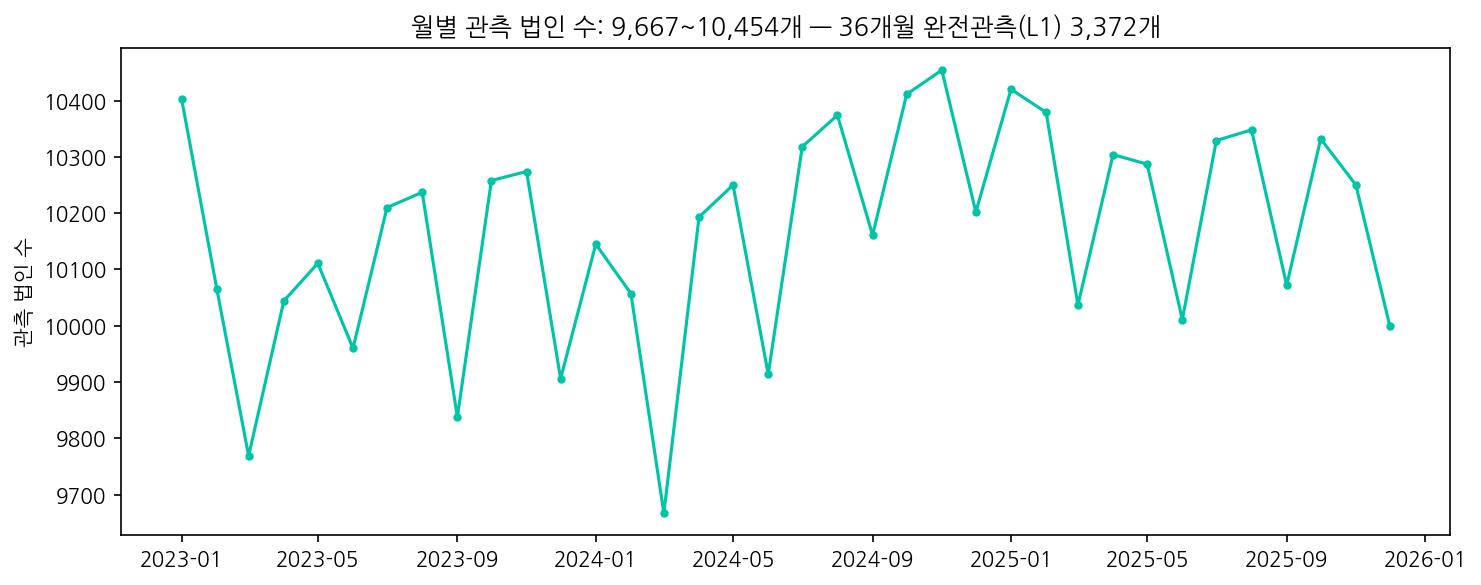

36개월 완전관측(L1): 3,372개 / 관측월 수 분포 상위:
기준년월
36    3372
35    1412
34     736
33     518
32     408


In [3]:
obs = df.groupby(YM)[ID].nunique()
per_corp = df.groupby(ID)[YM].nunique()
n_full = int((per_corp == 36).sum())

fig, ax = plt.subplots(figsize=(10, 4))
x = pd.to_datetime(obs.index.astype(str), format='%Y%m')
ax.plot(x, obs.values, color=IM['민트'], marker='o', ms=3, lw=1.5)
ax.set_ylabel('관측 법인 수')
ax.set_title(f'월별 관측 법인 수: {obs.min():,}~{obs.max():,}개 — 36개월 완전관측(L1) {n_full:,}개')
plt.tight_layout(); save_fig(fig, '01_01_월별관측법인수.png'); plt.show()

print(f'36개월 완전관측(L1): {n_full:,}개 / 관측월 수 분포 상위:')
print(per_corp.value_counts().sort_index(ascending=False).head(5).to_string())
assert n_full == 3372

**해석 —** (법인ID, 기준년월) 중복 0건으로 패널 구조는 깨끗하다. 결측은 **사업장_시도·시군구 2개 컬럼에만 각 12,424행(3.4%, 474개 법인)** 존재한다(§4 사전 기록에 없던 신규 발견) — 수치 컬럼 결측은 0건이므로 모델 입력에는 영향이 없고, 프로필 인코딩 시 '미상' 범주 처리 방식을 03 노트북에서 상의한다. 전체 15,473개 법인 중 36개월 모두 관측되는 법인은 **3,372개(21.8%)**뿐이며, 나머지는 중도 신규·이탈로 관측 기간이 짧다. 시계열 기반 급증·급감 탐지가 성립하려면 연속 관측이 전제이므로 **L1 = 3,372개**를 시계열 분석 모집단으로 확정한다.

## 2. 구조 발견 — 전 기간 0 컬럼, 여신 합계 구조, 신탁⊇퇴직연금

In [4]:
num_cols = [c for c in df.select_dtypes(include='number').columns if c != YM]
zero_amount = [c for c in num_cols if df[c].abs().sum() == 0]

cat_cols = [c for c in df.select_dtypes(include='object').columns if c != ID]
const_cat = {c: df[c].astype(str).str.strip().unique()[0]
             for c in cat_cols if df[c].astype(str).str.strip().nunique() == 1}

print('전 기간 0 금액 컬럼:', zero_amount if zero_amount else '없음')
print('단일값 고정 범주 컬럼:', const_cat if const_cat else '없음')
share0 = (df[num_cols] == 0).mean().sort_values(ascending=False)
print()
print('0 비중 상위 수치 컬럼:')
print((share0.head(8) * 100).round(1).astype(str).add('%').to_string())
print()
print(f"참고: 운전_주택자금대출잔액>0 {int((df['운전_주택자금대출잔액'] > 0).sum()):,}행 / "
      f"시설_주택자금대출잔액>0 {int((df['시설_주택자금대출잔액'] > 0).sum()):,}행")
print('→ 사전 기록(§4: 전 기간 0 컬럼 4개 즉시 제거)과 달리 실데이터에는 값이 존재 — 즉시 제거 규칙 적용 불가, 지침 §4·§8-1 수정 필요')

전 기간 0 금액 컬럼: 없음
단일값 고정 범주 컬럼: 없음

0 비중 상위 수치 컬럼:
시설_주택자금대출잔액        99.9%
운전_주택자금대출잔액        99.9%
운전_당좌대출잔액          99.5%
운전_외상매출채권담보대출잔액    99.0%
운전_무역금융잔액          98.8%
수익증권잔액             98.7%
시설_에너지절약시설대출잔액     98.6%
운전_할인어음잔액          98.2%

참고: 운전_주택자금대출잔액>0 287행 / 시설_주택자금대출잔액>0 287행
→ 사전 기록(§4: 전 기간 0 컬럼 4개 즉시 제거)과 달리 실데이터에는 값이 존재 — 즉시 제거 규칙 적용 불가, 지침 §4·§8-1 수정 필요


In [5]:
w_subs = ['운전_할인어음잔액','운전_당좌대출잔액','운전_일반자금대출잔액','운전_무역금융잔액',
          '운전_주택자금대출잔액','운전_기업구매자금대출잔액','운전_외상매출채권담보대출잔액','운전_기타운전자금대출잔액']
f_subs = ['시설_일반자금대출잔액','시설_에너지절약시설대출잔액','시설_주택자금대출잔액','시설_기타시설자금대출잔액']

w_sum, f_sum = df[w_subs].sum(axis=1), df[f_subs].sum(axis=1)
w_match = (df['여신_운전자금대출잔액'] == w_sum).mean()
f_match = (df['여신_시설자금대출잔액'] == f_sum).mean()
w_res = (df['여신_운전자금대출잔액'] - w_sum).abs()
f_res = (df['여신_시설자금대출잔액'] - f_sum).abs()
print(f'여신_운전자금대출잔액 = Σ운전_하위 8개: 완전일치 {w_match:.1%}, 불일치 행 잔차 중앙값 {w_res[w_res>0].median():.0f}백만원(라운딩 수준)')
print(f'여신_시설자금대출잔액 = Σ시설_하위 4개: 완전일치 {f_match:.1%}, 불일치 행 잔차 중앙값 {f_res[f_res>0].median():.0f}백만원')

여신_운전자금대출잔액 = Σ운전_하위 8개: 완전일치 95.9%, 불일치 행 잔차 중앙값 20백만원(라운딩 수준)


여신_시설자금대출잔액 = Σ시설_하위 4개: 완전일치 97.9%, 불일치 행 잔차 중앙값 30백만원


In [6]:
incl = (df['신탁잔액'] >= df['퇴직연금잔액']).mean()
pos = df[df['퇴직연금잔액'] > 0]
eq = (pos['신탁잔액'] == pos['퇴직연금잔액']).mean()
rho = stats.spearmanr(df['신탁잔액'], df['퇴직연금잔액']).statistic
r = stats.pearsonr(df['신탁잔액'], df['퇴직연금잔액']).statistic
print(f'신탁잔액 ≥ 퇴직연금잔액 성립: {incl:.2%}')
print(f'퇴직연금>0인 {len(pos):,}행 중 신탁==퇴직연금: {eq:.1%}')
print(f'Spearman ρ = {rho:.2f} / Pearson r = {r:.2f}')
print('→ 근거는 상관이 아니라 포함 관계: 퇴직연금은 신탁의 부분집합 ⇒ 순신탁잔액 = 신탁잔액 − 퇴직연금잔액 파생(§8-5)')

신탁잔액 ≥ 퇴직연금잔액 성립: 100.00%
퇴직연금>0인 67,797행 중 신탁==퇴직연금: 91.0%
Spearman ρ = 0.93 / Pearson r = 0.16
→ 근거는 상관이 아니라 포함 관계: 퇴직연금은 신탁의 부분집합 ⇒ 순신탁잔액 = 신탁잔액 − 퇴직연금잔액 파생(§8-5)


**해석 —** ① **전 기간 0 컬럼은 실측 결과 존재하지 않는다** — 사전 기록(§4·§8-1의 "4개 즉시 제거")과 배치되는 신규 발견으로, 즉시 제거 규칙은 폐기하고 0 비중이 극단적으로 높은 희소 컬럼(위 표)은 03 노트북에서 분산·0비중 수치를 근거로 개별 판단한다. ② 여신 상위 합계 = Σ하위 관계가 완전일치 **95.9%(운전)/97.9%(시설)**로 성립하고 불일치 잔차 중앙값이 20~30백만원(라운딩 수준)이므로, 모델 입력은 상위 합계 2개만 쓰고 하위 12개는 파생 재료로만 사용한다(다중공선성 1차 제거, §8-5). ③ 신탁≥퇴직연금이 **100.00%** 성립하고 퇴직연금>0인 67,797행의 **91.0%**에서 두 값이 같다(Spearman ρ=0.93, Pearson r=0.16) — 근거는 상관이 아니라 퇴직연금이 신탁의 **부분집합**이라는 포함 관계이므로, `순신탁잔액 = 신탁 − 퇴직연금`으로 분리해야 이중계상 없이 수신 구성을 볼 수 있다.

## 3. 범주 컬럼 인벤토리 — 구간형 29개 유니크값 전수, 프로필 6개 카디널리티 (인코딩 설계 §8-2·3·4의 입력)

In [7]:
bin_cols = [c for c in df.columns if c.endswith(('좌수', '개수', '건수'))]
print(f'구간형(문자열) 컬럼: {len(bin_cols)}개 (좌수·개수 {sum(1 for c in bin_cols if not c.endswith("건수"))} + 건수 {sum(1 for c in bin_cols if c.endswith("건수"))})')

rows = []
for c in bin_cols:
    u = sorted(df[c].astype(str).str.strip().unique())
    rows.append({'컬럼': c, '유니크': len(u), '값(정규화 후)': ' | '.join(u)})
bin_tab = pd.DataFrame(rows)
bin_tab.to_csv('../outputs/tables/01_구간형_유니크값_전수.csv', index=False, encoding='utf-8-sig')
display(bin_tab)

raw_vals = set()
for c in bin_cols:
    raw_vals |= set(df[c].astype(str).unique())
spaced = sorted(v for v in raw_vals if ' ' in v)
print(f'공백 포함 원시값(띄어쓰기 불규칙): {spaced}')
print('→ 서수 인코딩 전 strip·공백 정규화 필수 (§8-2)')

구간형(문자열) 컬럼: 29개 (좌수·개수 21 + 건수 8)


,컬럼,유니크,값(정규화 후)
0,요구불예금좌수,10,0개 | 10개초과 20개이하 | 1개 | 20개초과 30개이하 | 2개 | 2개초...
1,거치식예금좌수,10,0개 | 10개초과 20개이하 | 1개 | 20개초과 30개이하 | 2개 | 2개초...
2,적립식예금좌수,8,0개 | 10개초과 20개이하 | 1개 | 20개초과 30개이하 | 2개 | 2개초...
3,수익증권좌수,6,0개 | 10개초과 20개이하 | 1개 | 2개 | 2개초과 5개이하 | 5개초과 ...
4,신탁좌수,8,0개 | 10개초과 20개이하 | 1개 | 20개초과 30개이하 | 2개 | 2개초...
5,퇴직연금좌수,5,0개 | 1개 | 2개 | 2개초과 5개이하 | 5개초과 10개이하
6,여신_운전자금대출좌수,10,0개 | 10개초과 20개이하 | 1개 | 20개초과 30개이하 | 2개 | 2개초...
7,운전_할인어음좌수,5,0개 | 1개 | 2개 | 2개초과 5개이하 | 5개초과 10개이하
8,운전_당좌대출좌수,3,0개 | 1개 | 2개초과 5개이하
9,운전_일반자금대출좌수,8,0개 | 10개초과 20개이하 | 1개 | 20개초과 30개이하 | 2개 | 2개초...


공백 포함 원시값(띄어쓰기 불규칙): ['10개초과 20개이하', '10건초과 20건이하', '20개초과 30개이하', '20건초과 30건이하', '2개초과 5개이하', '2건초과 5건이하', '30개초과 40개이하', '30건초과 40건이하', '40개초과 50개이하', '40건초과 50건이하', '50개 초과', '50건 초과', '5개초과 10개이하', '5건초과 10건이하']
→ 서수 인코딩 전 strip·공백 정규화 필수 (§8-2)


In [8]:
prof = ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '법인_고객등급', '전담고객여부']
card_tab = pd.DataFrame({'카디널리티(결측 제외)': {c: df[c].nunique() for c in prof},
                         '결측 수': {c: int(df[c].isna().sum()) for c in prof}})
display(card_tab)
print('사업장_시도(권역):', sorted(df['사업장_시도'].dropna().unique()), '+ 결측(미상)')
print('법인_고객등급:', sorted(df['법인_고객등급'].dropna().unique()), '/ 전담고객여부:', sorted(df['전담고객여부'].dropna().unique()))

,카디널리티(결측 제외),결측 수
업종_대분류,18,0
업종_중분류,61,0
사업장_시도,5,12424
사업장_시군구,13,12424
법인_고객등급,3,0
전담고객여부,2,0


사업장_시도(권역): ['경북', '기타', '대구', '부울경', '수도권'] + 결측(미상)
법인_고객등급: ['우수', '일반', '최우수'] / 전담고객여부: ['N', 'Y']


**해석 —** 구간형 29개는 `'0개'~'50건 초과'` 형태의 문자열이며 **띄어쓰기 불규칙**이 실재하므로, §8-2의 구간 중앙값 매핑(strip·공백 정규화 포함)이 필수다. 프로필은 시도가 이미 5개 권역으로 집계되어 있어 원핫 대상이고, 업종_중분류·시군구는 카디널리티를 근거로 상위 N+기타 통합 또는 빈도 인코딩(Train만 fit)을 03 노트북에서 상의해 결정한다. 등급(일반<우수<최우수)·전담(N/Y)은 서수/이진 인코딩.

## 4. 법인 프로필 분포 (L1 3,372개, 2025-12 스냅샷)

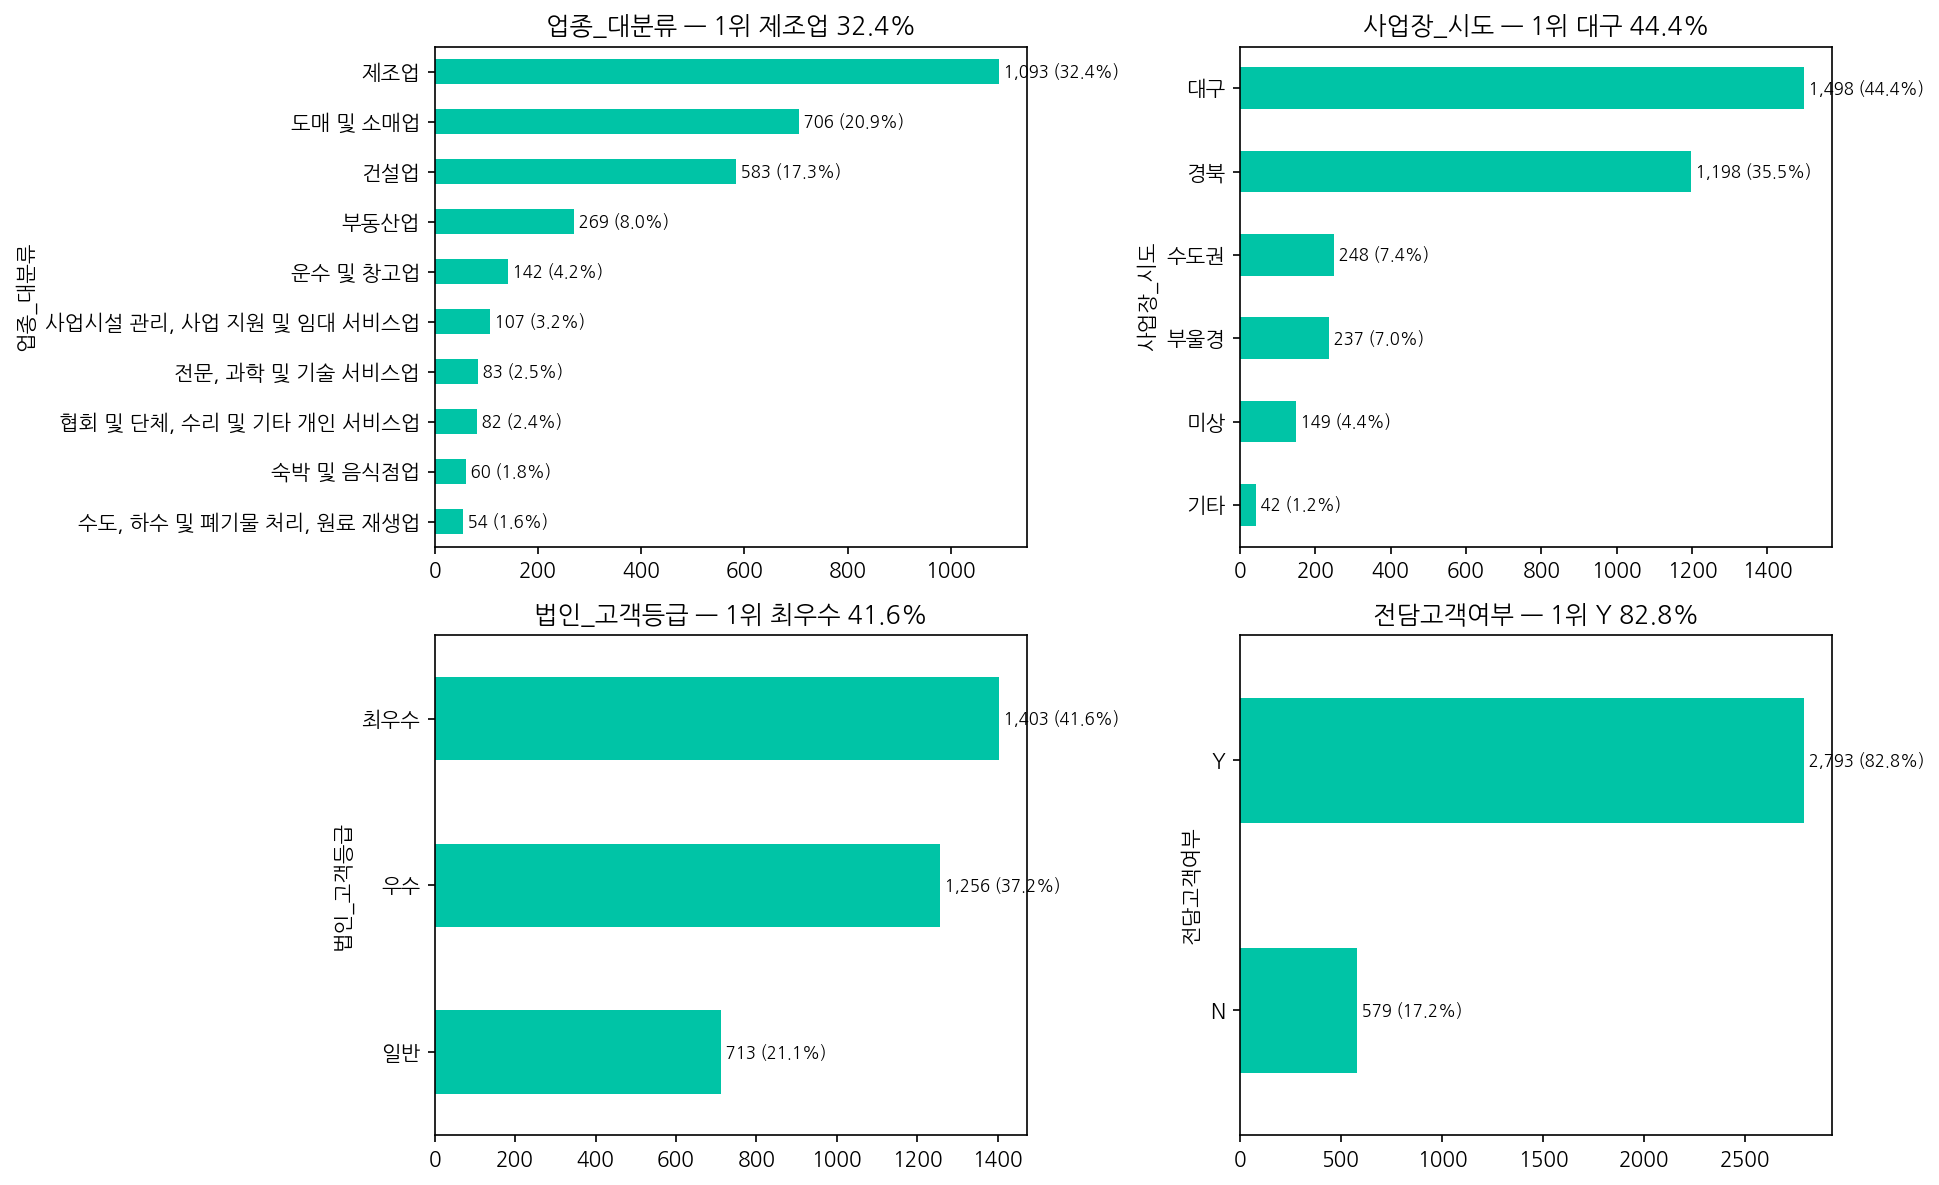

업종_대분류: 제조업 1,093개(32.4%), 도매 및 소매업 706개(20.9%), 건설업 583개(17.3%), 부동산업 269개(8.0%)
사업장_시도: 대구 1,498개(44.4%), 경북 1,198개(35.5%), 수도권 248개(7.4%), 부울경 237개(7.0%)
법인_고객등급: 최우수 1,403개(41.6%), 우수 1,256개(37.2%), 일반 713개(21.1%)
전담고객여부: Y 2,793개(82.8%), N 579개(17.2%)


In [9]:
ch = filtering_chain(df)
assert len(ch['l1_ids']) == 3372 and len(ch['l2_ids']) == 2819 and ch['k'] == 282
d1 = df[df[ID].isin(ch['l1_ids'])].copy()

snap = d1[d1[YM] == 202512].copy()
for c in ['업종_대분류', '사업장_시도', '법인_고객등급', '전담고객여부']:
    snap[c] = snap[c].fillna('미상')
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
panels = [('업종_대분류', 10), ('사업장_시도', None), ('법인_고객등급', None), ('전담고객여부', None)]
for ax, (col, topn) in zip(axes.ravel(), panels):
    vc = snap[col].value_counts()
    if topn: vc = vc.head(topn)
    share = vc / len(snap) * 100
    vc.iloc[::-1].plot.barh(ax=ax, color=IM['민트'])
    ax.set_title(f'{col} — 1위 {vc.index[0]} {share.iloc[0]:.1f}%')
    for i, v in enumerate(vc.iloc[::-1].values):
        ax.text(v, i, f' {v:,} ({v/len(snap)*100:.1f}%)', va='center', fontsize=8)
plt.tight_layout(); save_fig(fig, '01_02_프로필분포.png'); plt.show()

for col in ['업종_대분류', '사업장_시도', '법인_고객등급', '전담고객여부']:
    vc = snap[col].value_counts()
    print(f'{col}: ' + ', '.join(f'{k_} {v:,}개({v/len(snap)*100:.1f}%)' for k_, v in vc.head(4).items()))

**해석 —** L1(2025-12 스냅샷) 프로필: 업종은 제조업 1,093개(32.4%) > 도매·소매 706개(20.9%) > 건설 583개(17.3%) 순으로 지역 산업 구조를 반영하고, 권역은 **대구 44.4% + 경북 35.5% = 79.9%**로 iM뱅크의 지역은행 기반이 뚜렷하다. 등급은 최우수 41.6%·우수 37.2%(합산 78.8%), 전담 Y가 82.8% — L1 자체가 36개월 연속 거래한 장기 고객이라 우량 편중은 자연스럽다. 다만 이는 **L1 결과가 은행 전체 법인으로 일반화되지 않는다**는 한계이기도 하므로 결론 인용 시 병기한다.

## 5. 이상 월 탐지 — 등급 상/하향·전담 Y↔N 전환의 월별 집계 + z-score (§14-5)

등급전환 이상 월 202308: 552건 (평상시 월평균 117건 대비 ×4.7, z=5.5)
전담전환 이상 월 202501: 194건 (평상시 월평균 40건 대비 ×4.8, z=3.4)


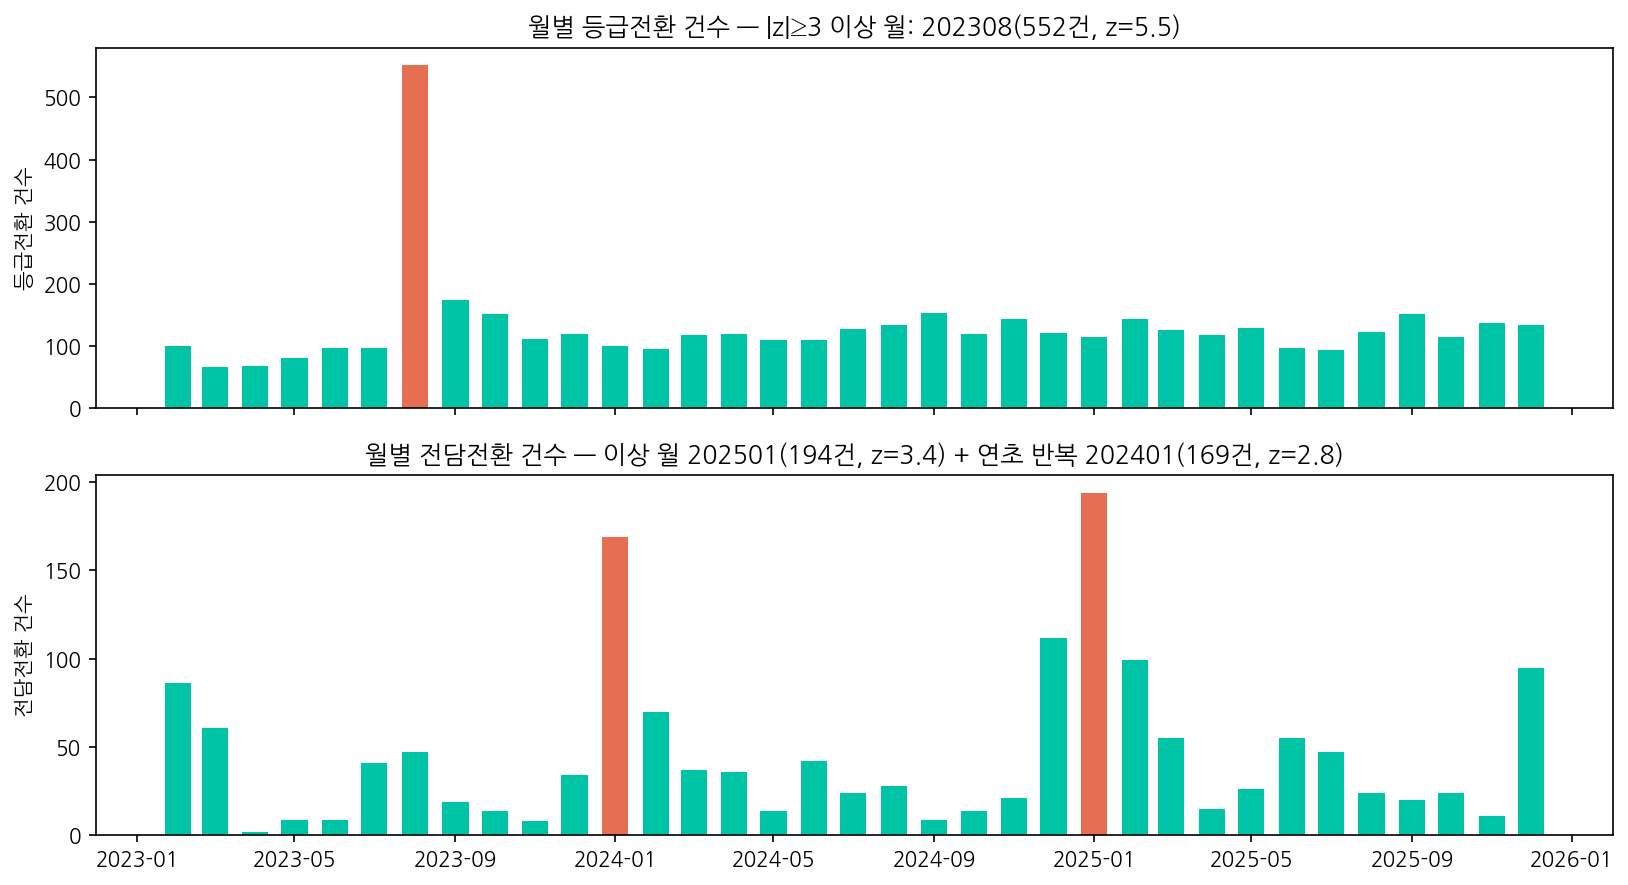

In [10]:
d1 = d1.sort_values([ID, YM])
d1['_등급'] = d1['법인_고객등급'].map({'일반': 0, '우수': 1, '최우수': 2})
assert d1['_등급'].notna().all(), '등급 매핑 실패 값 존재'
d1['_전담'] = (d1['전담고객여부'] == 'Y').astype(int)
g = d1.groupby(ID)
d1['_등급차'] = g['_등급'].diff()
d1['_전담차'] = g['_전담'].diff()

mon = d1[d1[YM] >= 202302].groupby(YM).agg(
    등급상향=('_등급차', lambda s: int((s > 0).sum())),
    등급하향=('_등급차', lambda s: int((s < 0).sum())),
    전담전환=('_전담차', lambda s: int((s != 0).sum())))
mon['등급전환'] = mon['등급상향'] + mon['등급하향']

anom_lines = []
for col in ['등급전환', '전담전환']:
    z = (mon[col] - mon[col].mean()) / mon[col].std()
    for ym_, zv in z[z.abs() >= 3].items():
        base = mon[col][mon[col].index != ym_].mean()
        anom_lines.append(f'{col} 이상 월 {ym_}: {mon[col][ym_]:,}건 (평상시 월평균 {base:.0f}건 대비 ×{mon[col][ym_]/base:.1f}, z={zv:.1f})')
print('\n'.join(anom_lines) if anom_lines else '|z|>=3 이상 월 없음')

x = pd.to_datetime(mon.index.astype(str), format='%Y%m')
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, col in zip(axes, ['등급전환', '전담전환']):
    z = (mon[col] - mon[col].mean()) / mon[col].std()
    colors = [IM['코랄'] if abs(v) >= 3 else IM['민트'] for v in z]
    if col == '전담전환':
        # 202401(169건, z=2.8)은 기준(3) 미달이나 202501과 동일한 '연초 급증' 반복 — 함께 강조
        colors[list(mon.index).index(202401)] = IM['코랄']
        ttl = f'월별 {col} 건수 — 이상 월 202501({mon[col][202501]}건, z={z[202501]:.1f}) + 연초 반복 202401({mon[col][202401]}건, z={z[202401]:.1f})'
    else:
        ttl_anom = ', '.join(f'{i}({mon[col][i]}건, z={z[i]:.1f})' for i in z[z.abs() >= 3].index) or '없음'
        ttl = f'월별 {col} 건수 — |z|≥3 이상 월: {ttl_anom}'
    ax.bar(x, mon[col], width=20, color=colors)
    ax.set_ylabel(f'{col} 건수')
    ax.set_title(ttl)
plt.tight_layout(); save_fig(fig, '01_03_이상월탐지_등급전담전환.png'); plt.show()
mon.to_csv('../outputs/tables/01_이상월_등급전담전환.csv', encoding='utf-8-sig')

**해석 —** |z|≥3 이상 월 2개를 확인했다. ① **2023-08 등급전환 552건**(평상시 월평균 117건 대비 ×4.7, z=5.5) ② **2025-01 전담전환 194건**(평상시 월평균 40건 대비 ×4.8, z=3.4). 참고로 **2024-01 전담전환도 169건(z=2.8)**으로 기준(3)에는 살짝 못 미치나 2025-01과 동일한 **'1월 연초 급증' 패턴의 반복**이다 — 연초 조직(전담 배정) 개편이라는 추정을 강화하는 정황이라 그림에 함께 강조했다. 두 해 모두 특정 방향으로의 일괄 변화 양상이며, 내부 등급 재산정·연초 조직 개편 등 **은행 내부 이벤트로 추정**된다(단정 불가 — 가상 데이터 한계). 등급·전담 관련 피처(등급_변화플래그 등)를 만들 때 이 월들의 전환은 법인 개별 신호가 아닌 일괄 이벤트일 수 있으므로, **해당 월 플래그 처리 방식은 03 노트북에서 상의 후 결정한다(§15).**

## 6. 카드 사용 심층 — 아티팩트·지배 법인·전무 법인·파레토·L0→L3 깔때기

L3 선정 기준(팀 합의·누수 방지): **Train 기준월 구간(202304~202403) 총 신용카드사용금액 상위 10%.**

2023-01 카드사용금액 0 비율: 100.0% (전 법인 0 — 수집 아티팩트) / 2023-02 활성(>0): 2,611개
→ 모든 시계열 시각화·통계는 2023-02부터 (§4)
카드 총액 1위 법인 점유율: 39.9% (2위 0.96%) → 지배 법인 1개 제외
36개월 내내 카드 0인 전무 법인: 552개 → 제외
L2 (카드 분석 모집단) = 3,372 − 1 − 552 = 2,819개
L2 양수 월관측 91,087건: 왜도 34.6, 중앙값 3.6 / 평균 7.3 / 최대 2,000백만원


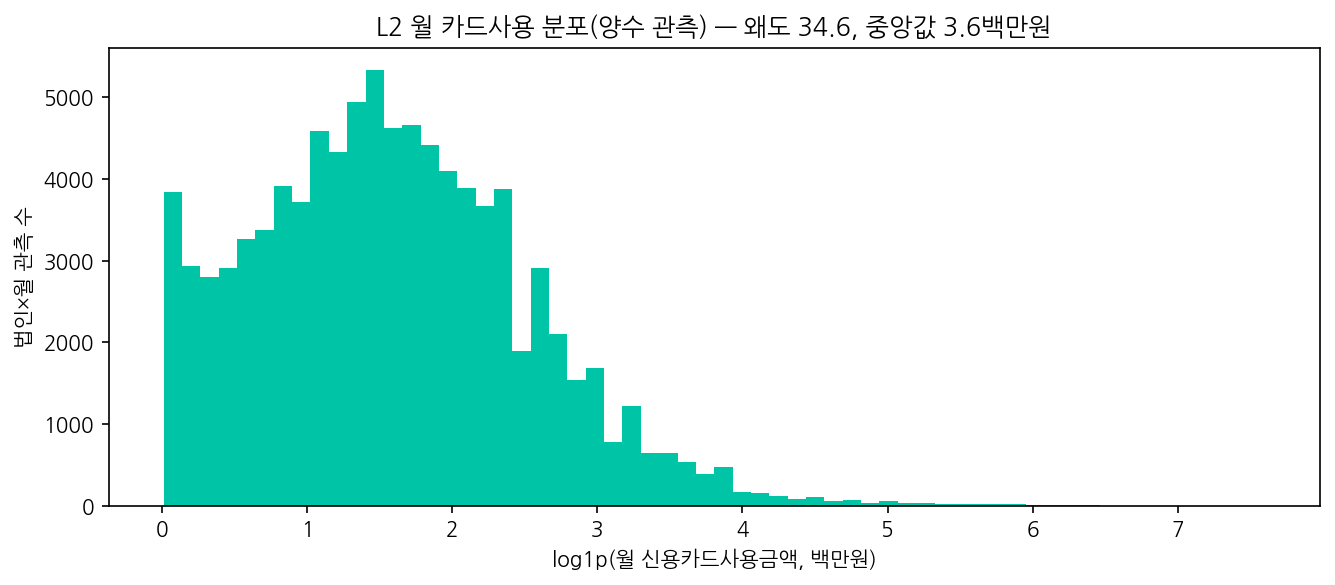

In [11]:
jan = d1[d1[YM] == 202301][CARD]
feb_active = int((d1[d1[YM] == 202302][CARD] > 0).sum())
print(f'2023-01 카드사용금액 0 비율: {(jan == 0).mean():.1%} (전 법인 0 — 수집 아티팩트) / 2023-02 활성(>0): {feb_active:,}개')
print('→ 모든 시계열 시각화·통계는 2023-02부터 (§4)')

tot36 = ch['tot36']
print(f'카드 총액 1위 법인 점유율: {tot36.iloc[0]/tot36.sum():.1%} (2위 {tot36.iloc[1]/tot36.sum():.2%}) → 지배 법인 1개 제외')
print(f'36개월 내내 카드 0인 전무 법인: {len(ch["zero36_ids"]):,}개 → 제외')
print(f'L2 (카드 분석 모집단) = 3,372 − 1 − {len(ch["zero36_ids"])} = {len(ch["l2_ids"]):,}개')

pos = d1[d1[ID].isin(ch['l2_ids']) & (d1[CARD] > 0)][CARD]
print(f'L2 양수 월관측 {len(pos):,}건: 왜도 {stats.skew(pos):.1f}, 중앙값 {pos.median():.1f} / 평균 {pos.mean():.1f} / 최대 {pos.max():,.0f}백만원')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log1p(pos), bins=60, color=IM['민트'])
ax.set_xlabel('log1p(월 신용카드사용금액, 백만원)'); ax.set_ylabel('법인×월 관측 수')
ax.set_title(f'L2 월 카드사용 분포(양수 관측) — 왜도 {stats.skew(pos):.1f}, 중앙값 {pos.median():.1f}백만원')
plt.tight_layout(); save_fig(fig, '01_04_카드사용분포.png'); plt.show()

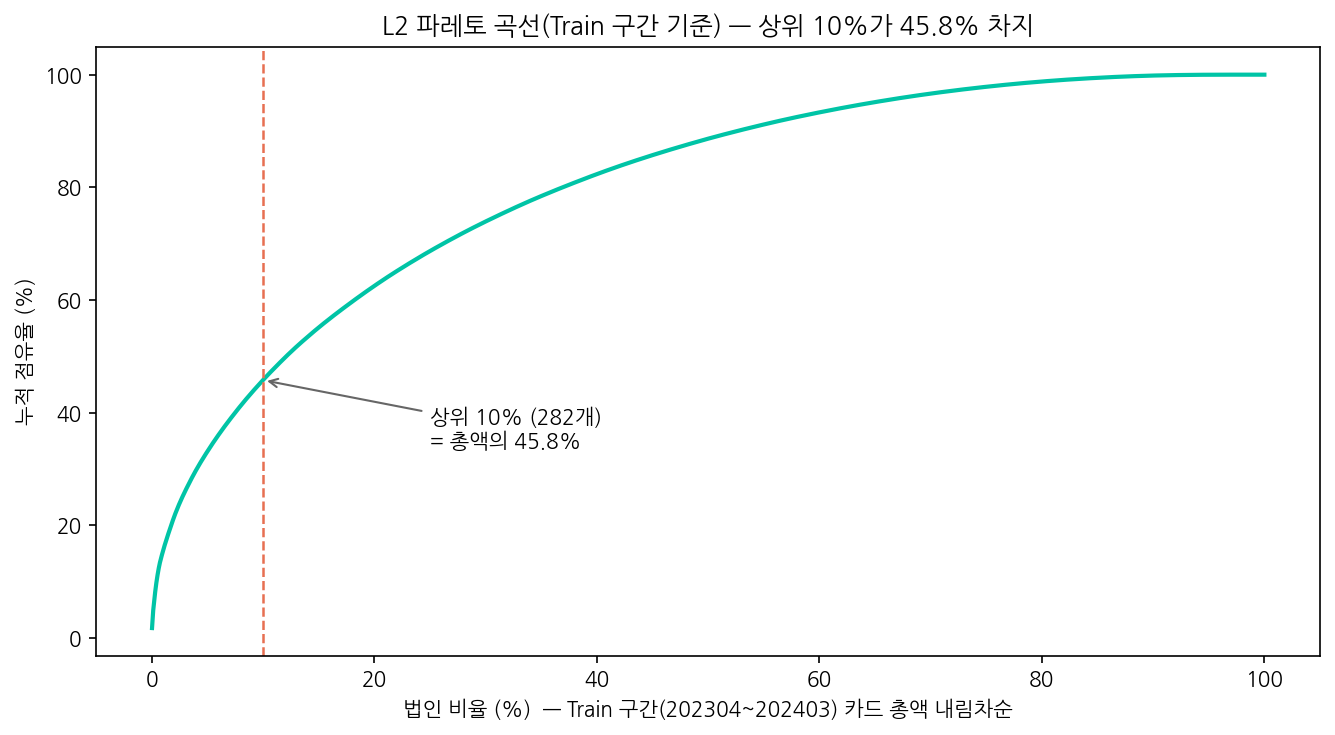

L3 = 282개 (컷 174.5백만원, 동률 1건)
구 기준(36개월 전체 총액) 상위 282개와 겹침: 244개(86.5%) — 38개 교체
→ 36개월 기준은 Holdout 정보 유입(누수)이므로 Train 구간 기준으로 확정 (§5)
L2 중 Train 구간 카드 0인 법인: 68개 (L3 진입 불가)


In [12]:
tt = ch['train_total']
k = ch['k']
cum = tt.cumsum() / tt.sum()
top_share = cum.iloc[k-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(cum)+1) / len(cum) * 100, cum.values * 100, color=IM['민트'], lw=2)
ax.axvline(10, color=IM['코랄'], ls='--', lw=1.2)
ax.annotate(f'상위 10% ({k}개)\n= 총액의 {top_share:.1%}', xy=(10, top_share*100),
            xytext=(25, top_share*100 - 12), arrowprops=dict(arrowstyle='->', color=IM['그레이']))
ax.set_xlabel('법인 비율 (%)  — Train 구간(202304~202403) 카드 총액 내림차순')
ax.set_ylabel('누적 점유율 (%)')
ax.set_title(f'L2 파레토 곡선(Train 구간 기준) — 상위 10%가 {top_share:.1%} 차지')
plt.tight_layout(); save_fig(fig, '01_05_파레토곡선.png'); plt.show()

old_top = ch['tot36'].loc[list(ch['l2_ids'])].sort_values(ascending=False).head(k).index
overlap = len(set(old_top) & set(ch['l3_ids']))
print(f'L3 = {k}개 (컷 {tt.iloc[k-1]:.1f}백만원, 동률 {int((tt == tt.iloc[k-1]).sum())}건)')
print(f'구 기준(36개월 전체 총액) 상위 {k}개와 겹침: {overlap}개({overlap/k:.1%}) — {k-overlap}개 교체')
print(f'→ 36개월 기준은 Holdout 정보 유입(누수)이므로 Train 구간 기준으로 확정 (§5)')
print(f'L2 중 Train 구간 카드 0인 법인: {int((tt == 0).sum())}개 (L3 진입 불가)')

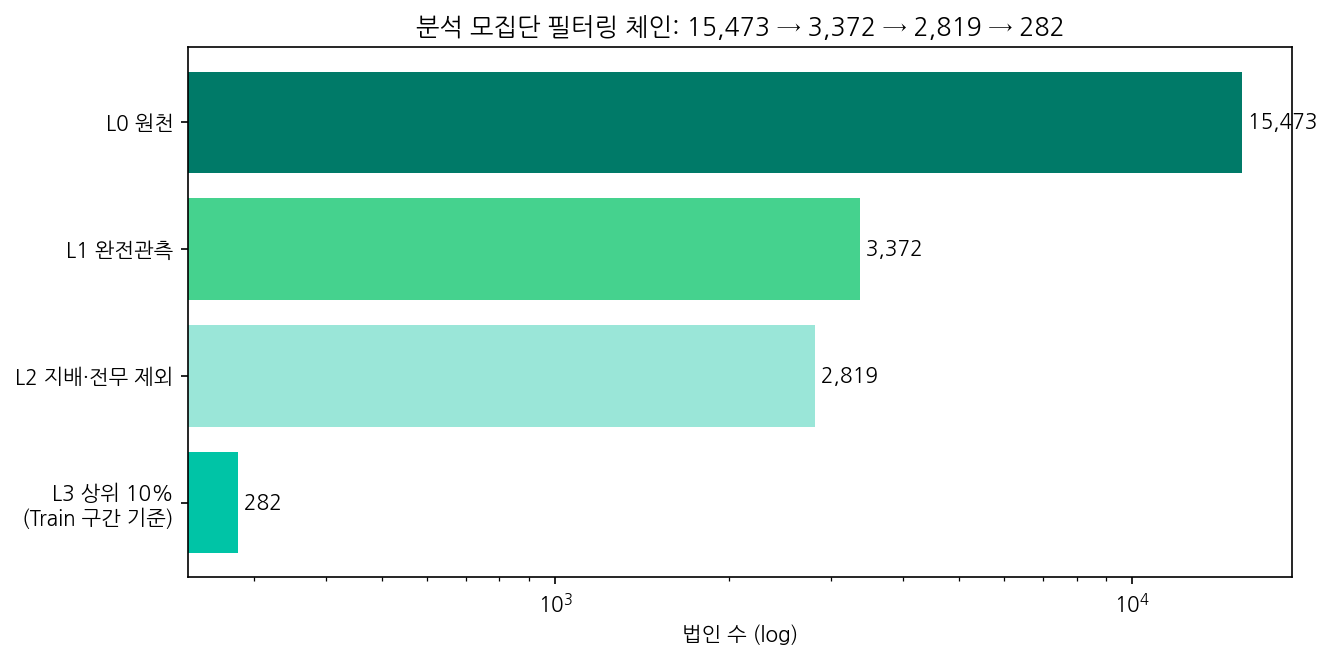

L3 목록 저장: data/processed/L3_법인목록.parquet — 282 개 (이후 노트북은 load_l3()만 사용)


In [13]:
funnel = [('L0 원천', 15473), ('L1 완전관측', 3372), ('L2 지배·전무 제외', 2819), ('L3 상위 10%\n(Train 구간 기준)', 282)]
fig, ax = plt.subplots(figsize=(9, 4.5))
names = [f[0] for f in funnel][::-1]
vals = [f[1] for f in funnel][::-1]
bars = ax.barh(names, vals, color=[IM['딥민트'], IM['그린'], IM['연민트'], IM['민트']][::-1])
for b, v in zip(bars, vals):
    ax.text(v, b.get_y() + b.get_height()/2, f' {v:,}', va='center')
ax.set_xscale('log'); ax.set_xlabel('법인 수 (log)')
ax.set_title('분석 모집단 필터링 체인: 15,473 → 3,372 → 2,819 → 282')
plt.tight_layout(); save_fig(fig, '01_06_필터링깔때기.png'); plt.show()

l3_df = pd.DataFrame({'법인ID': list(ch['l3_ids']),
                      'train구간_카드총액_백만원': tt.head(k).values,
                      '순위': range(1, k+1)})
common.save_l3(l3_df)
print('L3 목록 저장: data/processed/L3_법인목록.parquet —', len(l3_df), '개 (이후 노트북은 load_l3()만 사용)')

**해석 —** ① 2023-01은 전 법인 카드 0(수집 아티팩트)이므로 시계열 축은 2023-02부터 시작한다. ② 1위 법인이 전체 카드 총액의 39.9%(2위 0.96%)를 지배해 어떤 집계도 왜곡시키므로 제외하고, 36개월 내내 카드 0인 552개는 "카드 이용 패턴 변화"라는 과제 정의상 관측 대상이 아니므로 제외한다(단, 이 정의는 미래 정보를 포함하므로 한계로 명시 — §5 상의 항목). ③ 잔여 2,819개 중 **Train 구간(202304~202403) 카드 총액 상위 10% = 282개**가 해당 구간 총액의 45.8%를 차지한다 — 소수 집중 구조이므로 상위군 관리가 곧 카드 사업 관리다(주제3의 기여손익 관점). 구 기준(36개월) 대비 38개가 교체되어 기준 선택이 실제로 모집단을 바꿈을 확인했다. ④ 월 카드사용 분포는 극우편향(왜도 수치는 위 출력)이라 딥러닝 입력은 log1p가 필요하다(§8-6).

## 7. 시계열·계절성 — 월별 총액·중앙값 추이(2023-02~), YoY 패턴, 상위 10% vs 나머지

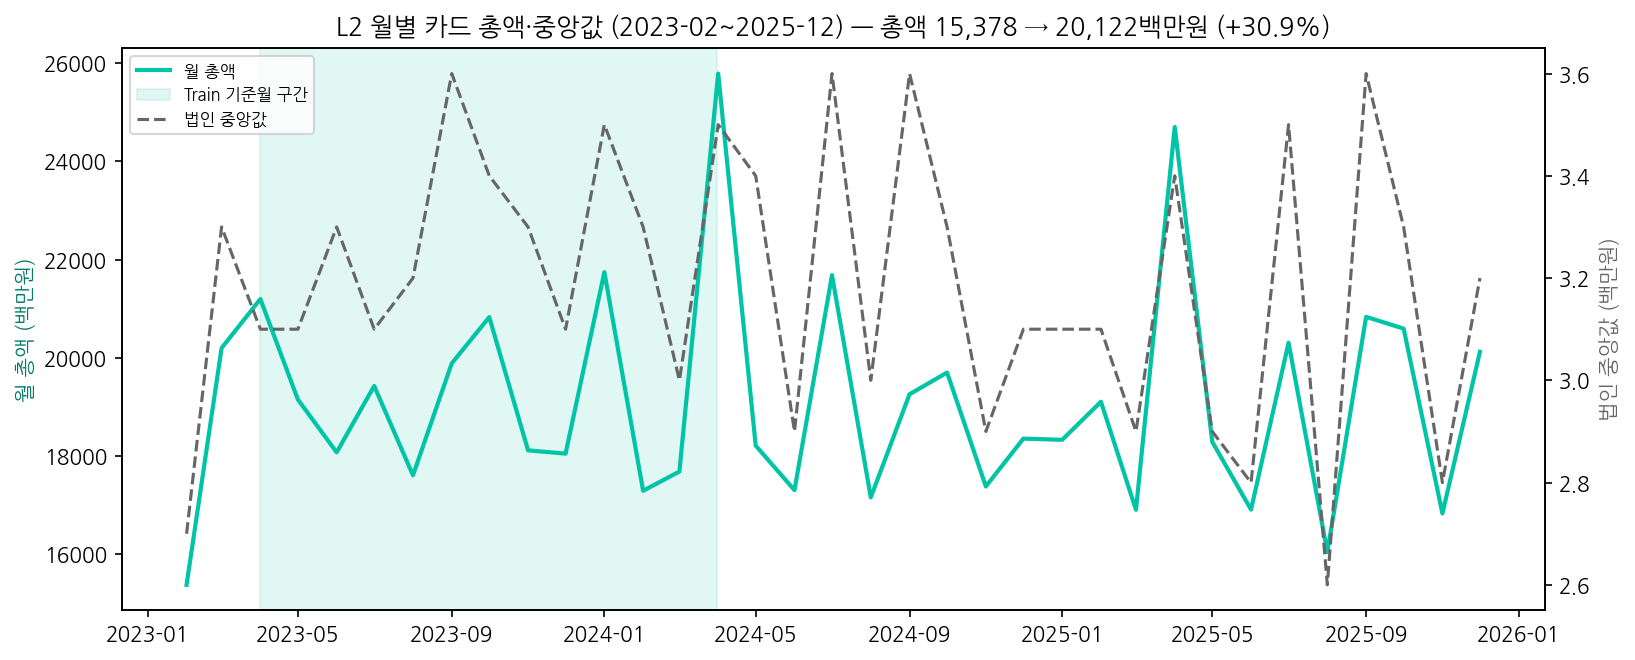

In [14]:
l2d = d1[d1[ID].isin(ch['l2_ids']) & (d1[YM] >= 202302)].copy()
m = l2d.groupby(YM)[CARD].agg(총액='sum', 중앙값='median', 평균='mean')
x = pd.to_datetime(m.index.astype(str), format='%Y%m')

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(x, m['총액'], color=IM['민트'], lw=2, label='월 총액')
ax1.axvspan(pd.Timestamp('2023-04-01'), pd.Timestamp('2024-03-31'), color=IM['연민트'], alpha=0.3, label='Train 기준월 구간')
ax1.set_ylabel('월 총액 (백만원)', color=IM['딥민트'])
ax2 = ax1.twinx()
ax2.plot(x, m['중앙값'], color=IM['그레이'], lw=1.5, ls='--', label='법인 중앙값')
ax2.set_ylabel('법인 중앙값 (백만원)', color=IM['그레이'])
first, last = m['총액'].iloc[0], m['총액'].iloc[-1]
ax1.set_title(f'L2 월별 카드 총액·중앙값 (2023-02~2025-12) — 총액 {first:,.0f} → {last:,.0f}백만원 ({(last/first-1)*100:+.1f}%)')
h1, l1 = ax1.get_legend_handles_labels(); h2, l2_ = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2_, loc='upper left', fontsize=8)
plt.tight_layout(); save_fig(fig, '01_07_월별카드추이.png'); plt.show()
m.to_csv('../outputs/tables/01_월별카드총액.csv', encoding='utf-8-sig')

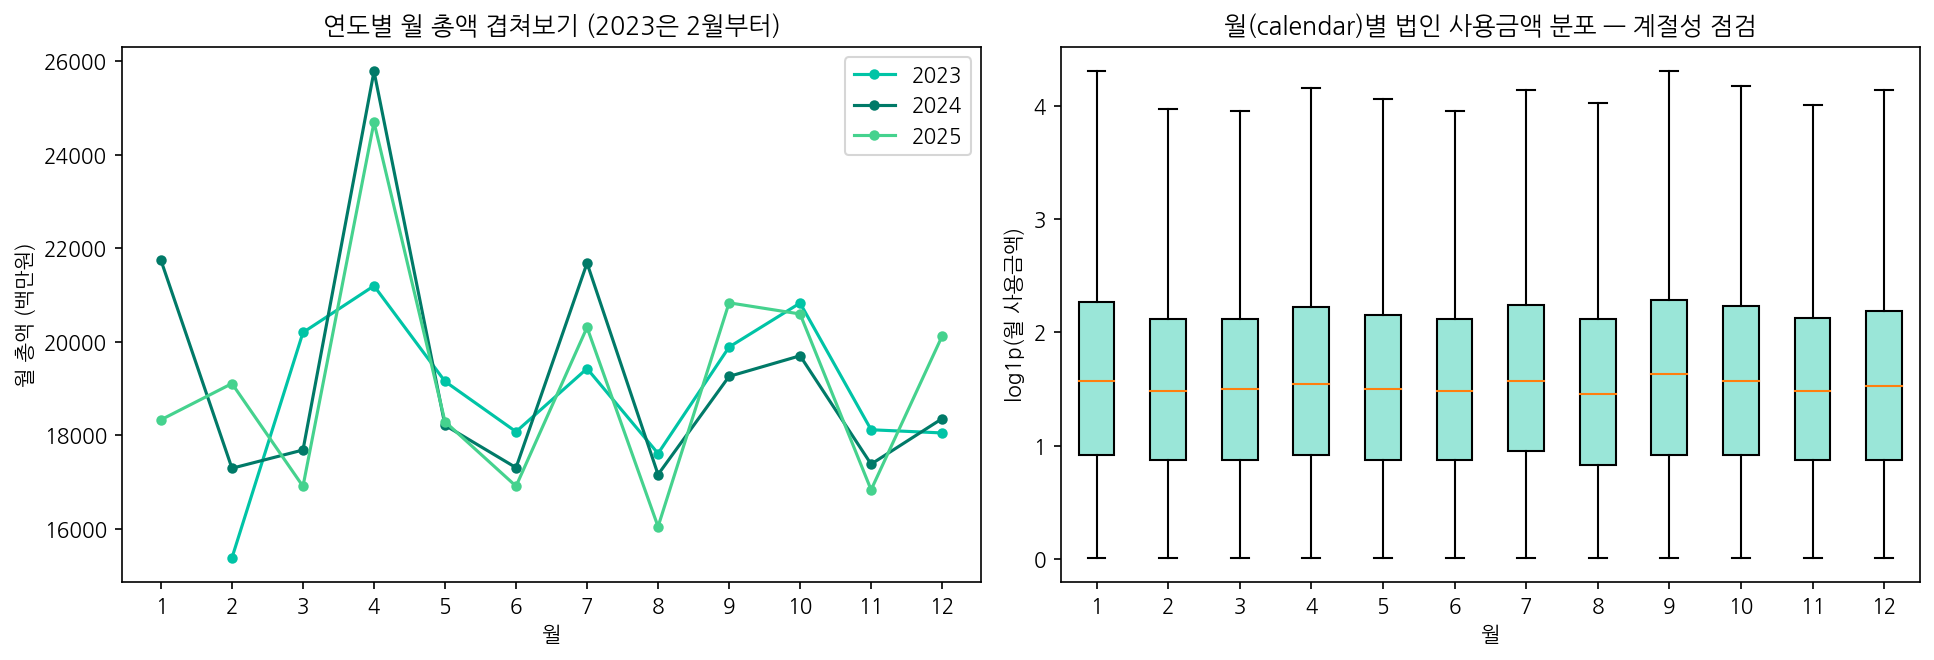

연도     2023     2024     2025
월                            
1       NaN  21745.0  18331.0
2   15378.0  17294.0  19107.0
3   20200.0  17685.0  16906.0
4   21198.0  25789.0  24701.0
5   19152.0  18213.0  18290.0
6   18076.0  17307.0  16910.0
7   19428.0  21684.0  20309.0
8   17609.0  17159.0  16044.0
9   19888.0  19260.0  20835.0
10  20830.0  19701.0  20595.0
11  18118.0  17382.0  16832.0
12  18050.0  18356.0  20122.0


In [15]:
tmp = m.reset_index()
tmp['연도'] = tmp[YM] // 100
tmp['월'] = tmp[YM] % 100
piv = tmp.pivot(index='월', columns='연도', values='총액')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, (yr, s) in enumerate(piv.items()):
    axes[0].plot(s.index, s.values, marker='o', ms=4, color=SERIES[i], label=str(yr))
axes[0].set_xticks(range(1, 13)); axes[0].set_xlabel('월'); axes[0].set_ylabel('월 총액 (백만원)')
yoy24 = (piv[2024].sum() / piv[2023].loc[2:].sum() - 1) * 100
axes[0].set_title('연도별 월 총액 겹쳐보기 (2023은 2월부터)')
axes[0].legend()

box_data = [l2d[l2d[YM] % 100 == mth][CARD].pipe(lambda s: np.log1p(s[s > 0])) for mth in range(1, 13)]
bp = axes[1].boxplot(box_data, labels=range(1, 13), patch_artist=True, showfliers=False)
for patch in bp['boxes']: patch.set_facecolor(IM['연민트'])
axes[1].set_xlabel('월'); axes[1].set_ylabel('log1p(월 사용금액)')
axes[1].set_title('월(calendar)별 법인 사용금액 분포 — 계절성 점검')
plt.tight_layout(); save_fig(fig, '01_08_YoY월별패턴.png'); plt.show()
print(piv.round(0).to_string())

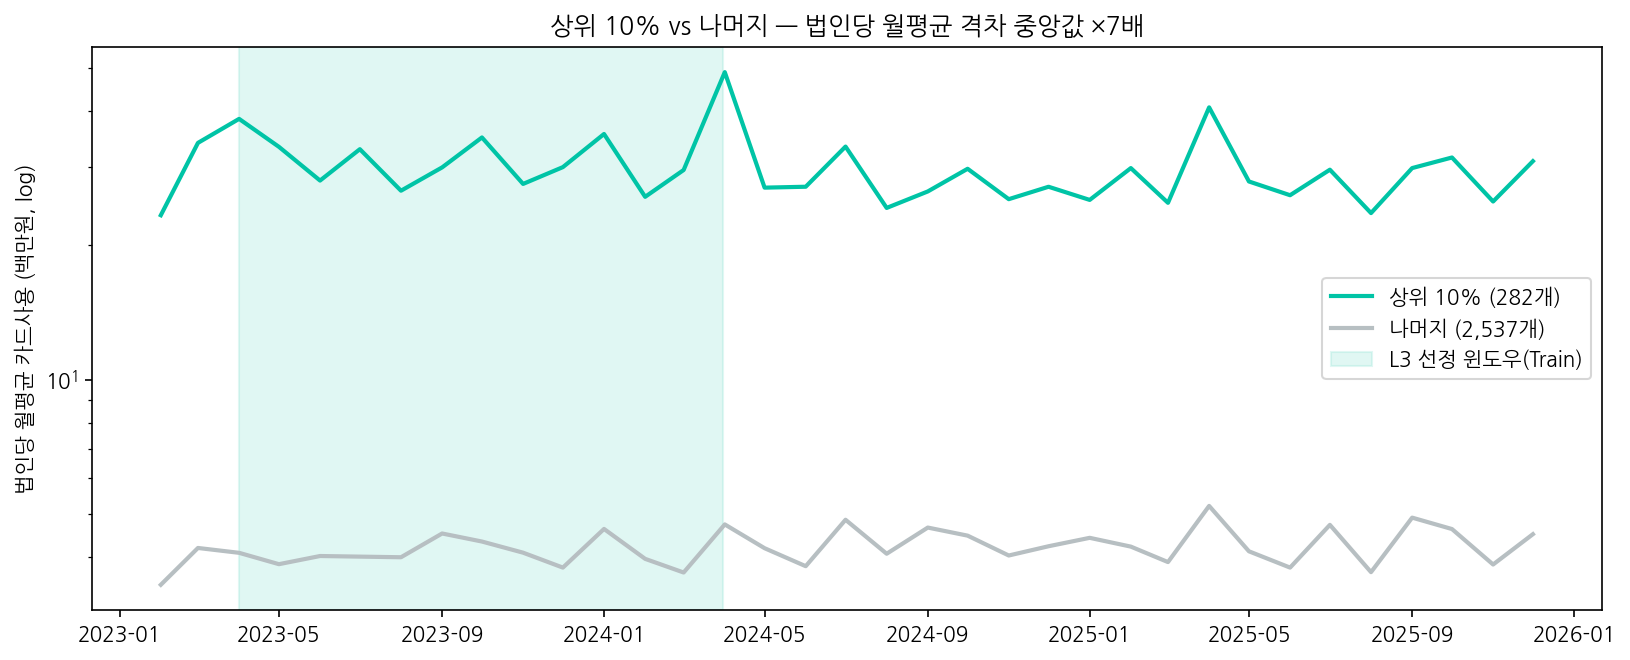

격차(상위/나머지) 중앙값: ×6.7
선정 윈도우 이후(202404~) 상위군 평균의 추이 유지 여부는 궤적으로 확인 — 수치: 윈도우 내 평균 31 vs 이후 평균 29백만원


In [16]:
l2d['군'] = np.where(l2d[ID].isin(ch['l3_ids']), '상위 10% (282개)', '나머지 (2,537개)')
traj = l2d.groupby(['군', YM])[CARD].mean().unstack(0)
x = pd.to_datetime(traj.index.astype(str), format='%Y%m')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x, traj['상위 10% (282개)'], color=IM['민트'], lw=2, label='상위 10% (282개)')
ax.plot(x, traj['나머지 (2,537개)'], color=IM['중립'], lw=2, label='나머지 (2,537개)')
ax.axvspan(pd.Timestamp('2023-04-01'), pd.Timestamp('2024-03-31'), color=IM['연민트'], alpha=0.3, label='L3 선정 윈도우(Train)')
ax.set_yscale('log'); ax.set_ylabel('법인당 월평균 카드사용 (백만원, log)')
ratio = (traj['상위 10% (282개)'] / traj['나머지 (2,537개)']).median()
ax.set_title(f'상위 10% vs 나머지 — 법인당 월평균 격차 중앙값 ×{ratio:.0f}배')
ax.legend()
plt.tight_layout(); save_fig(fig, '01_09_상위10_vs_나머지.png'); plt.show()
print(f'격차(상위/나머지) 중앙값: ×{ratio:.1f}')
print(f'선정 윈도우 이후(202404~) 상위군 평균의 추이 유지 여부는 궤적으로 확인 — 수치: 윈도우 내 평균 {traj.loc[202304:202403, "상위 10% (282개)"].mean():,.0f} vs 이후 평균 {traj.loc[202404:, "상위 10% (282개)"].mean():,.0f}백만원')

**해석 —** ① L2 월 카드 총액은 16,044~25,789백만원 대역에서 등락하며 뚜렷한 장기 성장 추세는 없다(2024년 동월 합계 대비 2025년 −1.1% 수준의 정체). ② 계절성은 **4월 피크가 3개년 연속 반복**(2023-04 21,198 / 2024-04 25,789 / 2025-04 24,701백만원 — 각 연도 최고치)되고 8월·11월이 상대적 저점 — 기준월 month의 sin/cos 또는 분기 더미 피처(§9-⑤)의 근거. ③ 상위 10%(282개)와 나머지의 법인당 월평균 격차는 **중앙값 ×6.7배**로 전 기간 안정적이며, L3 선정 윈도우(202304~202403) 이후에도 상위군 평균이 31 → 29백만원으로 소폭(−6.5%) 하락에 그쳐 — 선정 효과의 평균회귀는 있으나 상위군 지위 자체는 유지된다. 즉 Train 구간 기준 선정이 Holdout 기간에도 유효한 상위군을 가리킨다.

## 8. 연관 신호 1차 — 카드 증감 vs 총수신·총여신·디지털채널 증감 (탐지 가치의 예고편)

In [17]:
l2m = d1[d1[ID].isin(ch['l2_ids'])].sort_values([ID, YM]).copy()
l2m['총수신'] = l2m[['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액']].sum(axis=1)
l2m['총여신'] = l2m['여신_운전자금대출잔액'] + l2m['여신_시설자금대출잔액']
l2m['디지털채널금액'] = l2m['인터넷뱅킹거래금액'] + l2m['스마트뱅킹거래금액']
l2m['요구불_순유입'] = l2m['요구불입금금액'] - l2m['요구불출금금액']

g = l2m.groupby(ID)
for c in [CARD, '총수신', '총여신', '디지털채널금액']:
    l2m['Δ' + c] = g[c].diff()

sub = l2m[l2m[YM] >= 202303].dropna(subset=['Δ' + CARD])
targets = {'Δ총수신': 'Δ총수신', 'Δ총여신': 'Δ총여신', 'Δ디지털채널금액': 'Δ디지털채널금액', '요구불_순유입': '요구불_순유입(수준)'}
rows, rhos = [], {}
for col, label in targets.items():
    rho_ = stats.spearmanr(sub['Δ' + CARD], sub[col]).statistic
    rhos[label] = rho_
    rows.append({'상대 변수': label, 'Spearman ρ (vs Δ카드)': round(rho_, 3)})
corr_tab = pd.DataFrame(rows)
display(corr_tab)
corr_tab.to_csv('../outputs/tables/01_카드증감_연관신호.csv', index=False, encoding='utf-8-sig')
print(f'표본: L2 법인×월 {len(sub):,}건 (202303~202512)')

,상대 변수,Spearman ρ (vs Δ카드)
0,Δ총수신,0.008
1,Δ총여신,-0.005
2,Δ디지털채널금액,0.046
3,요구불_순유입(수준),0.008


표본: L2 법인×월 95,846건 (202303~202512)


**해석 —** 동월(MoM) 증감 간 Spearman 상관은 Δ총수신 0.008, Δ총여신 −0.005, Δ디지털채널 0.046, 요구불_순유입 0.008로 **사실상 0**이다(표본 95,846건). 당초 기대("카드 급변은 은행 관계 전반의 변화와 동행")는 **동시 상관 수준에서는 기각**된다 — 과장 없이 그대로 보고한다. 시사점 두 가지: ① 카드 사용 급변은 수신·여신·채널의 동월 변화로 **대체 관측이 불가능**하므로, 이를 3개월 선행 탐지하는 모델은 다른 지표 모니터링으로 대신할 수 없는 **독자적 가치**를 가진다. ② 은행 관계 변수는 동월 '증감'이 아니라 수준·구조(보유상품 수, 여신한도 소진율, 디지털 비중 등) 형태로 예측에 기여할 가능성이 남아 있으며, 시차(선행/후행) 관계는 **02 노트북의 이벤트 스터디(급증·급감 t0 전후 ±6개월 궤적)**에서 재검증한다.

## 9. L3(282개) 심층 — 내부 집중도, 규모 vs 변동성, 프로필 편중, 은행 관계 깊이

핵심 모델링 군 282개가 "어떤 법인들이고, 급증·급감이 어디서 나올 구조인지"를 확인한다.

,카드월평균_중앙값,총수신_중앙값,총여신_중앙값,여신한도_중앙값,상품보유수_중앙값,디지털비중_중앙값,카드보유율,외환활동율,자동이체사용율,최우수비중,전담비중
군,,,,,,,,,,,
L3 상위10% (282),20.921,164.457,938.714,219.143,4.0,0.919,1.000,0.103,1.000,0.748,0.965
"L2−L3 (2,537)",3.213,50.720,405.143,50.000,3.0,0.926,0.961,0.079,1.000,0.405,0.841
전무 (552),0.000,10.082,300.000,0.000,2.0,0.820,0.178,0.051,0.971,0.297,0.701


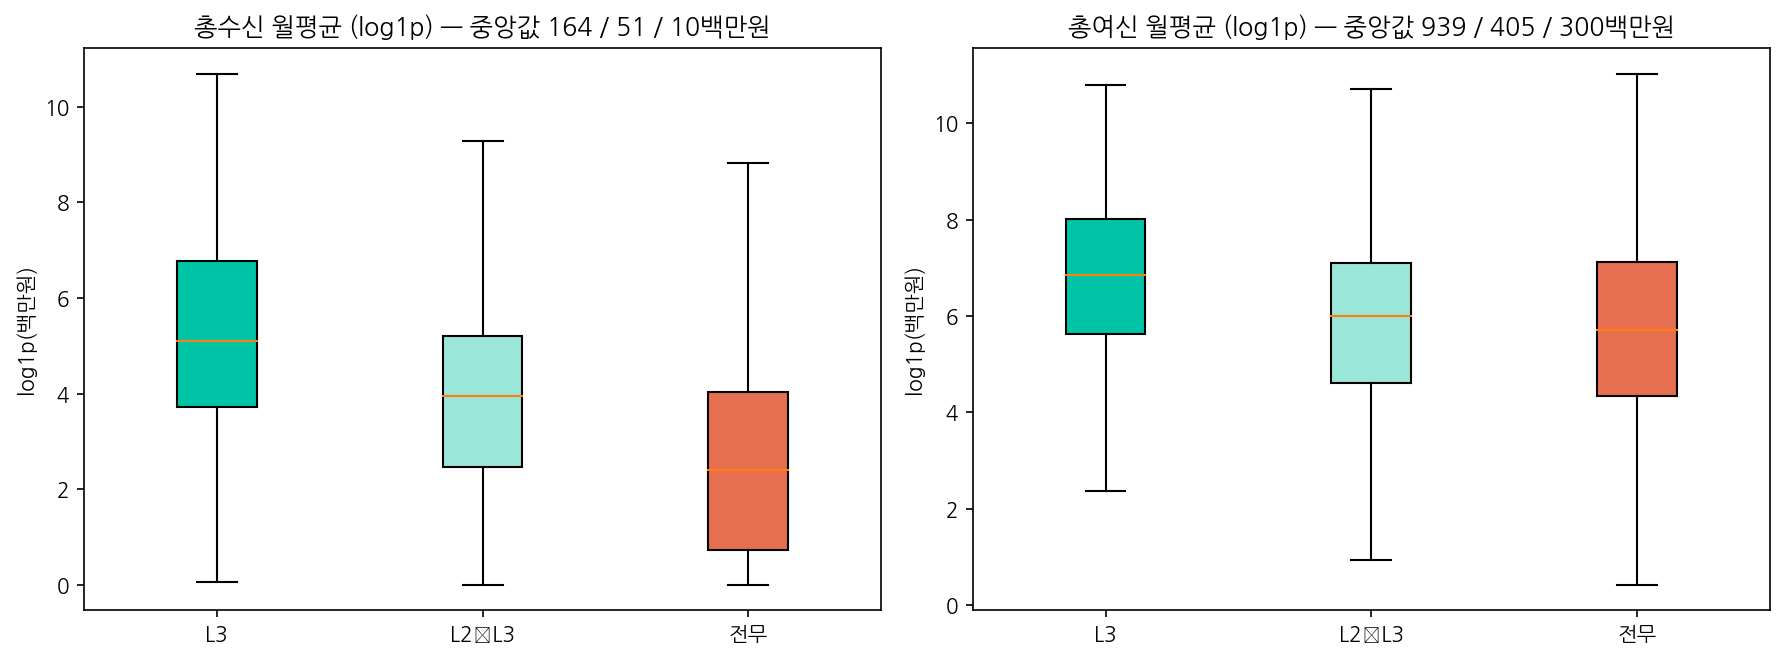

In [18]:
use = d1[d1[YM] >= 202302].copy()
use['총수신'] = use[['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액']].sum(axis=1)
use['총여신'] = use['여신_운전자금대출잔액'] + use['여신_시설자금대출잔액']
use['디지털금액'] = use['인터넷뱅킹거래금액'] + use['스마트뱅킹거래금액']
use['채널총액'] = use[['창구거래금액', '인터넷뱅킹거래금액', '스마트뱅킹거래금액', '폰뱅킹거래금액', 'ATM거래금액']].sum(axis=1)
use['외환실적'] = use['외환_수출실적금액'] + use['외환_수입실적금액']

agg = use.groupby(ID).agg(
    카드월평균=(CARD, 'mean'), 카드표준편차=(CARD, 'std'),
    카드활성월=(CARD, lambda s: int((s > 0).sum())),
    체크월평균=('체크카드사용금액', 'mean'),
    체크활성월=('체크카드사용금액', lambda s: int((s > 0).sum())),
    총수신월평균=('총수신', 'mean'), 총여신월평균=('총여신', 'mean'),
    여신한도월평균=('여신한도금액', 'mean'),
    디지털합=('디지털금액', 'sum'), 채널합=('채널총액', 'sum'),
    자동이체합=('자동이체금액', 'sum'), 외환합=('외환실적', 'sum'))
agg['디지털비중'] = np.where(agg['채널합'] > 0, agg['디지털합'] / agg['채널합'], np.nan)

snap12 = d1[d1[YM] == 202512].set_index(ID)
prod_cols = {'요구불': '요구불예금좌수', '거치식': '거치식예금좌수', '적립식': '적립식예금좌수',
             '수익증권': '수익증권좌수', '신탁': '신탁좌수', '퇴직연금': '퇴직연금좌수',
             '운전여신': '여신_운전자금대출좌수', '시설여신': '여신_시설자금대출좌수'}
for name, c in prod_cols.items():
    agg['보유_' + name] = (snap12[c].astype(str).str.strip() != '0개').reindex(agg.index)
agg['상품보유수'] = agg[['보유_' + n for n in prod_cols]].sum(axis=1)
agg['카드보유'] = (snap12['신용카드개수'].astype(str).str.strip() != '0개').reindex(agg.index)
for c in ['업종_대분류', '사업장_시도', '법인_고객등급', '전담고객여부']:
    agg[c] = snap12[c].fillna('미상').reindex(agg.index)

grp = pd.Series('L2−L3 (2,537)', index=agg.index)
grp[agg.index.isin(ch['l3_ids'])] = 'L3 상위10% (282)'
grp[agg.index.isin(ch['zero36_ids'])] = '전무 (552)'
grp[agg.index == ch['dominant_id']] = '지배(제외)'
agg['군'] = grp
core = agg[agg['군'] != '지배(제외)'].copy()
order = ['L3 상위10% (282)', 'L2−L3 (2,537)', '전무 (552)']

summ = core.groupby('군').agg(
    카드월평균_중앙값=('카드월평균', 'median'), 총수신_중앙값=('총수신월평균', 'median'),
    총여신_중앙값=('총여신월평균', 'median'), 여신한도_중앙값=('여신한도월평균', 'median'),
    상품보유수_중앙값=('상품보유수', 'median'), 디지털비중_중앙값=('디지털비중', 'median'),
    카드보유율=('카드보유', 'mean'), 외환활동율=('외환합', lambda s: (s > 0).mean()),
    자동이체사용율=('자동이체합', lambda s: (s > 0).mean()),
    최우수비중=('법인_고객등급', lambda s: (s == '최우수').mean()),
    전담비중=('전담고객여부', lambda s: (s == 'Y').mean())).loc[order]
display(summ.round(3))
summ.to_csv('../outputs/tables/01_군별_요약.csv', encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, ttl in zip(axes, ['총수신월평균', '총여신월평균'], ['총수신 월평균', '총여신 월평균']):
    data = [np.log1p(core.loc[core['군'] == g, col]) for g in order]
    bp = ax.boxplot(data, labels=[g.split(' ')[0] for g in order], patch_artist=True, showfliers=False)
    for patch, c in zip(bp['boxes'], [IM['민트'], IM['연민트'], IM['코랄']]):
        patch.set_facecolor(c)
    meds = [core.loc[core['군'] == g, col].median() for g in order]
    ax.set_title(f'{ttl} (log1p) — 중앙값 {meds[0]:,.0f} / {meds[1]:,.0f} / {meds[2]:,.0f}백만원')
    ax.set_ylabel('log1p(백만원)')
plt.tight_layout(); save_fig(fig, '01_10_군별_은행관계.png'); plt.show()

L3 내부 집중: 상위 10개가 L3 Train 총액의 19.1%, 상위 50개가 43.9%
L3 카드 활성월(35개월 중, 202302~): 중앙값 35개월 / 35개월 전부 사용 267개(94.7%)


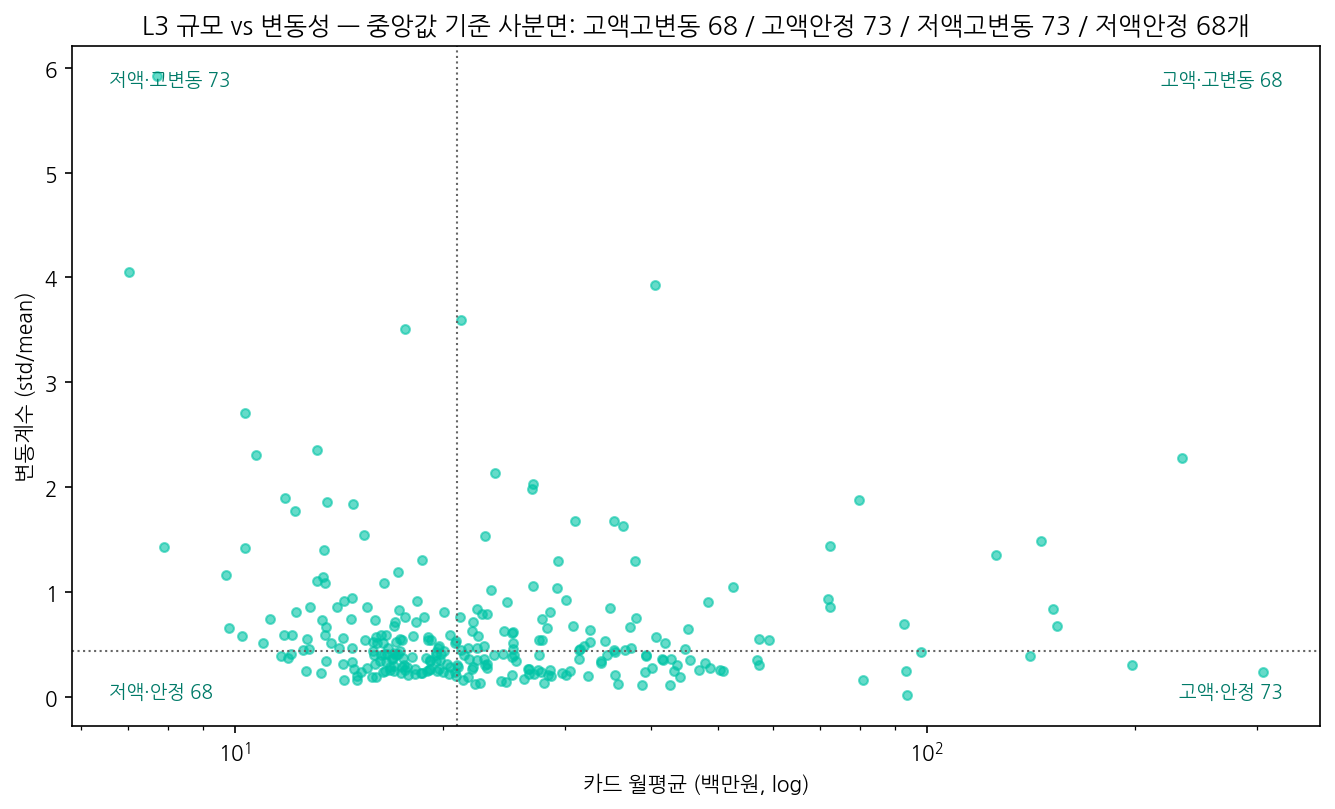

사분면(중앙값 기준): 고액고변동 68 / 고액안정 73 / 저액고변동 73 / 저액안정 68
변동계수 분포: 중앙값 0.44, 상위 10% 1.31


In [19]:
l3a = core[core['군'] == 'L3 상위10% (282)'].copy()
tt_l3 = ch['train_total'].head(ch['k'])
top10_share = tt_l3.head(10).sum() / tt_l3.sum()
top50_share = tt_l3.head(50).sum() / tt_l3.sum()
print(f'L3 내부 집중: 상위 10개가 L3 Train 총액의 {top10_share:.1%}, 상위 50개가 {top50_share:.1%}')
print(f'L3 카드 활성월(35개월 중, 202302~): 중앙값 {l3a["카드활성월"].median():.0f}개월 / 35개월 전부 사용 {int((l3a["카드활성월"]==35).sum())}개({(l3a["카드활성월"]==35).mean():.1%})')

l3a['변동계수'] = l3a['카드표준편차'] / l3a['카드월평균']
mx, my = l3a['카드월평균'].median(), l3a['변동계수'].median()
q_hh = int(((l3a['카드월평균'] >= mx) & (l3a['변동계수'] >= my)).sum())
q_hl = int(((l3a['카드월평균'] >= mx) & (l3a['변동계수'] < my)).sum())
q_lh = int(((l3a['카드월평균'] < mx) & (l3a['변동계수'] >= my)).sum())
q_ll = int(((l3a['카드월평균'] < mx) & (l3a['변동계수'] < my)).sum())

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(l3a['카드월평균'], l3a['변동계수'], s=18, alpha=0.6, color=IM['민트'])
ax.set_xscale('log')
ax.axvline(mx, color=IM['그레이'], ls=':', lw=1)
ax.axhline(my, color=IM['그레이'], ls=':', lw=1)
ax.set_xlabel('카드 월평균 (백만원, log)'); ax.set_ylabel('변동계수 (std/mean)')
ax.set_title(f'L3 규모 vs 변동성 — 중앙값 기준 사분면: 고액고변동 {q_hh} / 고액안정 {q_hl} / 저액고변동 {q_lh} / 저액안정 {q_ll}개')
for txt, xy in [(f'고액·고변동 {q_hh}', (0.97, 0.95)), (f'고액·안정 {q_hl}', (0.97, 0.05)),
                (f'저액·고변동 {q_lh}', (0.03, 0.95)), (f'저액·안정 {q_ll}', (0.03, 0.05))]:
    ax.annotate(txt, xy=xy, xycoords='axes fraction',
                ha='right' if xy[0] > 0.5 else 'left', va='center', fontsize=9, color=IM['딥민트'])
plt.tight_layout(); save_fig(fig, '01_11_L3_규모vs변동성.png'); plt.show()
print(f'사분면(중앙값 기준): 고액고변동 {q_hh} / 고액안정 {q_hl} / 저액고변동 {q_lh} / 저액안정 {q_ll}')
print(f'변동계수 분포: 중앙값 {my:.2f}, 상위 10% {l3a["변동계수"].quantile(0.9):.2f}')

**해석 —** ① L3는 일회성 고액 사용자가 아니라 **상시 사용군**이다: 282개 중 267개(94.7%)가 2023-02 이후 35개월 전부 카드를 사용했고 활성월 중앙값도 35개월 — 급증·급감 라벨의 past 윈도우가 0이 되는 경우가 드물어 롤링 타겟 설계(§6)에 유리하다. ② 내부 집중은 완만하다: 상위 10개가 L3 Train 총액의 19.1%, 상위 50개가 43.9% — L0에서 본 1위 39.9% 같은 지배 구조가 없어 282개를 단일 모델로 다루는 것이 정당하다. ③ 규모 vs 변동성 사분면(중앙값 기준)은 고액·고변동 68 / 고액·안정 73 / 저액·고변동 73 / 저액·안정 68개로 고르게 분산되며, 변동계수 중앙값 0.44·상위 10% 1.31 — 급증·급감 라벨은 고변동 사분면(141개)에서 집중 발생할 것으로 예상되므로 **02에서 라벨×사분면 교차표로 검증한다.**

,L3 %,L2−L3 %,배율(L3/L2−L3)
항목,,,
업종:제조업,33.33,33.82,0.99
업종:건설업,21.99,18.29,1.20
업종:도매 및 소매업,19.86,21.76,0.91
업종:운수 및 창고업,5.67,4.06,1.40
"업종:전문, 과학 및 기술 서비스업",3.90,2.25,1.74
"업종:사업시설 관리, 사업 지원 및 임대 서비스업",2.84,3.07,0.92
권역:대구,43.62,45.25,0.96
권역:경북,37.94,36.78,1.03
권역:수도권,6.74,5.08,1.33


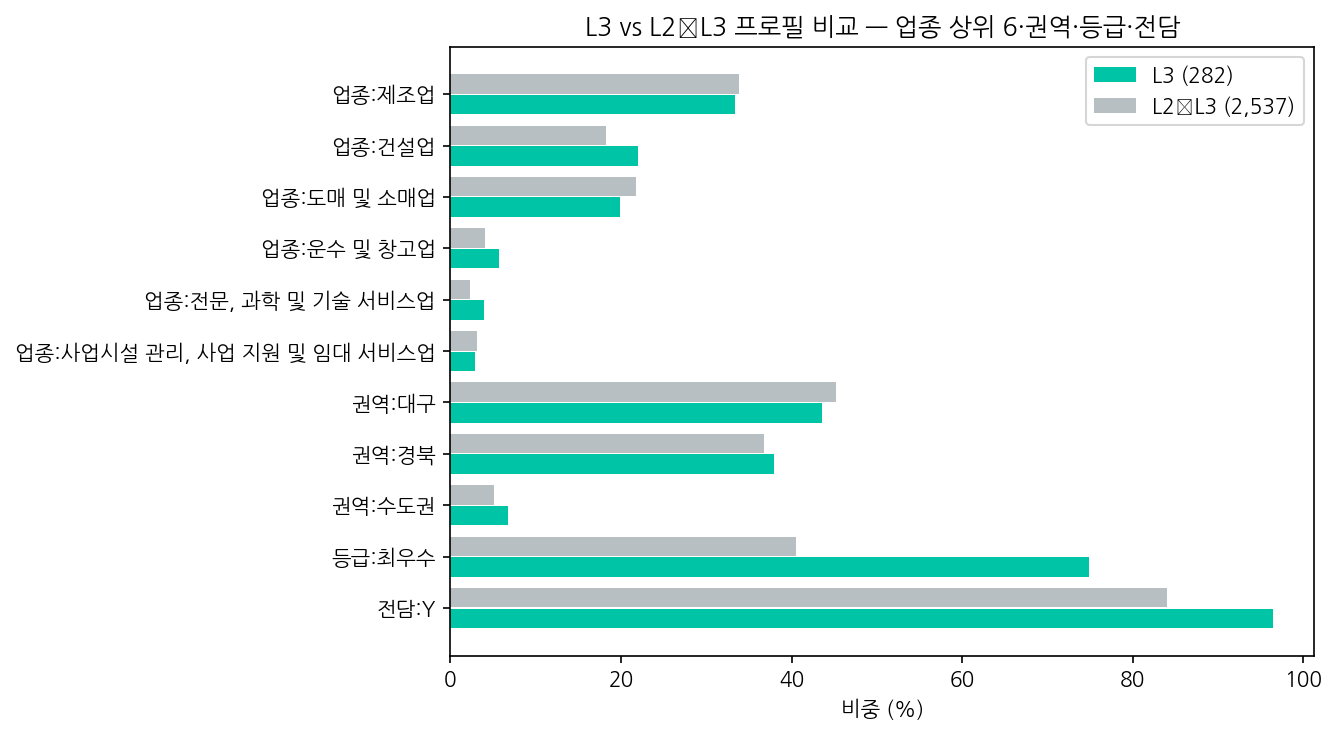

In [20]:
rest = core[core['군'] == 'L2−L3 (2,537)']
comp_rows = []
for cat in l3a['업종_대분류'].value_counts().head(6).index:
    comp_rows.append({'항목': f'업종:{cat}', 'L3': (l3a['업종_대분류'] == cat).mean(),
                      'L2−L3': (rest['업종_대분류'] == cat).mean()})
for cat in ['대구', '경북', '수도권']:
    comp_rows.append({'항목': f'권역:{cat}', 'L3': (l3a['사업장_시도'] == cat).mean(),
                      'L2−L3': (rest['사업장_시도'] == cat).mean()})
comp_rows.append({'항목': '등급:최우수', 'L3': (l3a['법인_고객등급'] == '최우수').mean(),
                  'L2−L3': (rest['법인_고객등급'] == '최우수').mean()})
comp_rows.append({'항목': '전담:Y', 'L3': (l3a['전담고객여부'] == 'Y').mean(),
                  'L2−L3': (rest['전담고객여부'] == 'Y').mean()})
comp = pd.DataFrame(comp_rows).set_index('항목')
comp['배율(L3/L2−L3)'] = comp['L3'] / comp['L2−L3']
display((comp * [100, 100, 1]).round(2).rename(columns={'L3': 'L3 %', 'L2−L3': 'L2−L3 %'}))
comp.to_csv('../outputs/tables/01_L3_프로필비교.csv', encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(9, 5))
yidx = np.arange(len(comp))
ax.barh(yidx + 0.2, comp['L3'] * 100, height=0.38, color=IM['민트'], label='L3 (282)')
ax.barh(yidx - 0.2, comp['L2−L3'] * 100, height=0.38, color=IM['중립'], label='L2−L3 (2,537)')
ax.set_yticks(yidx); ax.set_yticklabels(comp.index); ax.invert_yaxis()
ax.set_xlabel('비중 (%)'); ax.legend()
ax.set_title('L3 vs L2−L3 프로필 비교 — 업종 상위 6·권역·등급·전담')
plt.tight_layout(); save_fig(fig, '01_12_L3_프로필비교.png'); plt.show()

**해석 —** L3의 편중은 업종·권역이 아니라 **은행 관계 깊이**에서 나타난다. 업종 구성은 L2−L3와 거의 동일하고(제조업 33.3% vs 33.8%, 배율 0.99; 전문·과학기술 ×1.74, 운수·창고 ×1.40만 소폭 과대), 권역도 대구 43.6% vs 45.3%로 유사하다. 반면 **최우수 등급 74.8% vs 40.5%(×1.85)**, 전담 96.5% vs 84.1%, 여신한도 중앙값 219 vs 50백만원, 총수신 중앙값 164 vs 51백만원(§9 요약표), 카드보유율 100%로 관계 지표는 확연히 깊다. 즉 상위 10%는 "특정 업종 클럽"이 아니라 **"은행과 깊게 거래하는 법인"**이며, 업종 피처보다 관계 피처(여신한도 소진율·상품보유수·총수신 등)가 유효할 것이라는 예고다.

## 10. 전무 552개 심층 — "카드를 안 쓰는 법인"은 누구이고, 무엇으로 공략하나

36개월 카드 0인 552개는 급증·급감 모델의 대상이 아니다. 그러나 L1(36개월 완전관측)에 속한 **살아있는 거래 법인**이므로, 카드가 아닌 접점(비카드)으로 공략할 근거를 수치로 확인한다. §5의 "나머지 법인 활용 모델(b) 카드 미사용→활성화 예측" 결정의 입력이다.

[은행 관계] 전무 총수신 월평균 중앙값 10백만원 (L2 56) / 총여신 중앙값 300백만원 (L2 440)
  전무 중 총수신이 L2 중앙값 이상: 137개(24.8%)
  전무 중 여신 보유(총여신>0): 527개(95.5%)
  전무 상품보유수 중앙값 2개 (L2 3개) / 최우수 비중 29.7% (L2 43.9%)

[카드·채널 접점] 체크카드 사용 경험(월>0 존재): 0개(0.0%)
  신용카드 보유(2025-12 신용카드개수≠0개): 98개(17.8%) — 보유하되 36개월 미사용(휴면)
  디지털 채널 사용(인터넷+스마트>0): 445개(80.6%) / 디지털비중 중앙값 0.82
  자동이체 사용: 536개(97.1%) / 외환 실적 보유: 28개(5.1%)


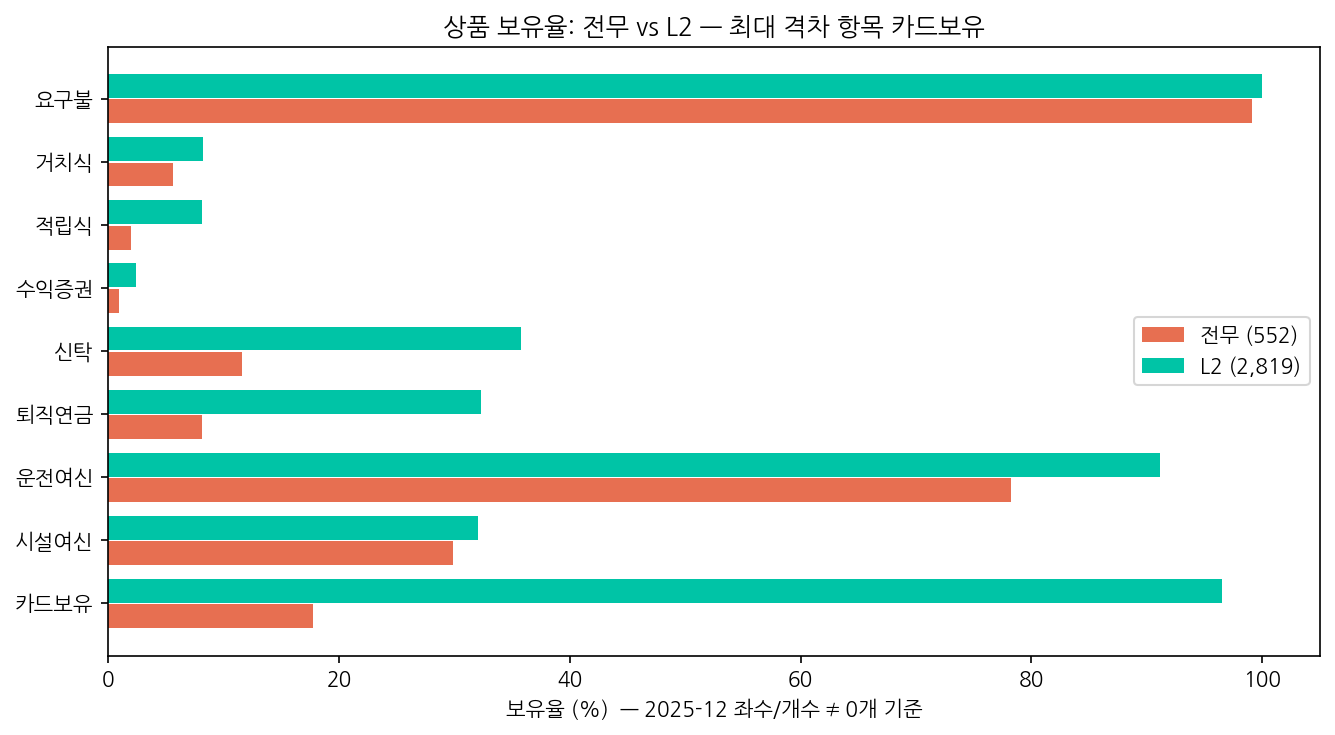

In [21]:
z = core[core['군'] == '전무 (552)']
l2all = core[core['군'] != '전무 (552)']  # L2 = L3 + (L2−L3)

med_dep_l2, med_loan_l2 = l2all['총수신월평균'].median(), l2all['총여신월평균'].median()
print(f'[은행 관계] 전무 총수신 월평균 중앙값 {z["총수신월평균"].median():,.0f}백만원 (L2 {med_dep_l2:,.0f}) / '
      f'총여신 중앙값 {z["총여신월평균"].median():,.0f}백만원 (L2 {med_loan_l2:,.0f})')
print(f'  전무 중 총수신이 L2 중앙값 이상: {int((z["총수신월평균"] >= med_dep_l2).sum())}개({(z["총수신월평균"] >= med_dep_l2).mean():.1%})')
print(f'  전무 중 여신 보유(총여신>0): {int((z["총여신월평균"] > 0).sum())}개({(z["총여신월평균"] > 0).mean():.1%})')
print(f'  전무 상품보유수 중앙값 {z["상품보유수"].median():.0f}개 (L2 {l2all["상품보유수"].median():.0f}개) / 최우수 비중 {(z["법인_고객등급"]=="최우수").mean():.1%} (L2 {(l2all["법인_고객등급"]=="최우수").mean():.1%})')
print()
print(f'[카드·채널 접점] 체크카드 사용 경험(월>0 존재): {int((z["체크활성월"] > 0).sum())}개({(z["체크활성월"] > 0).mean():.1%})')
print(f'  신용카드 보유(2025-12 신용카드개수≠0개): {int(z["카드보유"].sum())}개({z["카드보유"].mean():.1%}) — 보유하되 36개월 미사용(휴면)')
print(f'  디지털 채널 사용(인터넷+스마트>0): {int((z["디지털합"] > 0).sum())}개({(z["디지털합"] > 0).mean():.1%}) / 디지털비중 중앙값 {z["디지털비중"].median():.2f}')
print(f'  자동이체 사용: {int((z["자동이체합"] > 0).sum())}개({(z["자동이체합"] > 0).mean():.1%}) / 외환 실적 보유: {int((z["외환합"] > 0).sum())}개({(z["외환합"] > 0).mean():.1%})')

hold_items = ['보유_' + n for n in prod_cols] + ['카드보유']
hold = pd.DataFrame({'전무 (552)': z[hold_items].mean(), 'L2 (2,819)': l2all[hold_items].mean()})
hold.index = [i.replace('보유_', '') for i in hold.index]
fig, ax = plt.subplots(figsize=(9, 5))
yidx = np.arange(len(hold))
ax.barh(yidx + 0.2, hold['전무 (552)'] * 100, height=0.38, color=IM['코랄'], label='전무 (552)')
ax.barh(yidx - 0.2, hold['L2 (2,819)'] * 100, height=0.38, color=IM['민트'], label='L2 (2,819)')
ax.set_yticks(yidx); ax.set_yticklabels(hold.index); ax.invert_yaxis()
ax.set_xlabel('보유율 (%)  — 2025-12 좌수/개수 ≠ 0개 기준')
gap = (hold['L2 (2,819)'] - hold['전무 (552)']).abs().idxmax()
ax.set_title(f'상품 보유율: 전무 vs L2 — 최대 격차 항목 {gap}')
ax.legend()
plt.tight_layout(); save_fig(fig, '01_13_전무_상품보유율.png'); plt.show()
hold.to_csv('../outputs/tables/01_전무_상품보유율.csv', encoding='utf-8-sig')

**해석 —** 전무 552개는 죽은 고객이 아니다. ① **95.5%(527개)가 여신 보유**, 총여신 중앙값 300백만원(L2 440의 68% 수준) — **대출 중심의 단선 관계** 법인이다. ② 수신 쪽은 얕다: 총수신 중앙값 10백만원(L2 56), 상품보유수 중앙값 2개(L2 3개), 최우수 비중 29.7%(L2 43.9%). ③ 그러나 접점은 살아있다: 디지털 채널 사용 80.6%(디지털비중 중앙값 0.82), 자동이체 97.1%. ④ **체크카드 사용 경험 0개(0.0%)** — 신용카드만이 아니라 카드류 전반의 구조적 미사용. ⑤ 신용카드 보유는 98개(17.8%) — 카드를 갖고도 36개월간 한 번도 쓰지 않은 **휴면 보유군**. ⑥ 데이터 이슈: 전무군 여신한도 중앙값이 0인데 총여신 중앙값은 300백만원 — 한도 정보가 이 군에서 기록되지 않았을 가능성이 있어, 03의 `여신한도_소진율` 파생 시 **분모 0 처리 규칙이 필수**다.

In [22]:
print(f'체크카드 사용 경험 보유: {(z["체크활성월"] > 0).sum()}개 — 552개 전원 0. 신용카드만이 아니라 카드류 전반의 구조적 미사용')
print(f'신용카드 보유(휴면): {int(z["카드보유"].astype(bool).sum())}개 ({z["카드보유"].astype(bool).mean():.1%}) — 발급 없이 활성화만 필요한 최저 문턱 후보')

semi = core[(core['군'] == 'L2−L3 (2,537)')].join(ch['train_total'].rename('train총액'))
n_semi = int((semi['train총액'] == 0).sum())
print(f'참고: L2 중 Train 구간(202304~202403) 카드 0인 준전무 {n_semi}개 — 활성화 모델 논의 시 전무 552와 함께 검토')

체크카드 사용 경험 보유: 0개 — 552개 전원 0. 신용카드만이 아니라 카드류 전반의 구조적 미사용
신용카드 보유(휴면): 98개 (17.8%) — 발급 없이 활성화만 필요한 최저 문턱 후보
참고: L2 중 Train 구간(202304~202403) 카드 0인 준전무 68개 — 활성화 모델 논의 시 전무 552와 함께 검토


**해석 —** 전무 552개의 카드 접점: **체크카드 사용 경험 0(전원) / 신용카드 휴면 보유 98개(17.8%)** — 카드류 전반을 안 쓰는 구조적 미사용이 재확인된다. 휴면 98개는 발급 절차 없이 활성화만 하면 되는 가장 낮은 문턱의 전환 후보다. 이 552개(+Train 구간 카드 0인 준전무 68개)는 급증·급감 모델의 대상이 아니라 **§5 후보 (b) "카드 미사용→활성화 예측"의 모집단**이다 — 다만 발급·첫 사용 라벨이 본 데이터에 없으므로(36개월 내내 0이라 타겟 이벤트 자체가 미관측) 모델화 가능 여부와 방향은 07에서 팀과 확정한다(§5·§15).

## 11. 브리지 — EDA 발견 → 왜 "카드 급증·급감 탐지"인가 (발표 서사의 뼈대)

In [23]:
bridge = [
    f"[근거1] 36개월 완전관측 법인은 3,372개(전체의 21.8%) — 시계열 예측이 성립하는 모집단이 명확히 존재",
    f"[근거2] 1위 법인이 카드 총액의 39.9%를 지배(2위 0.96%), 전무 법인 552개 — 집계 왜곡원 제거 후 L2 2,819개 확보",
    f"[근거3] Train 구간(202304~202403) 기준 상위 10%(282개)가 L2 카드 총액의 {ch['train_total'].cumsum().iloc[ch['k']-1]/ch['train_total'].sum():.1%} 차지 — 소수 집중 구조라 상위군 급변 탐지의 비즈니스 레버리지가 큼",
    f"[근거4] 월 카드사용 분포 왜도 {stats.skew(pos):.1f}의 극우편향 + 상위군/나머지 격차 ×{ratio:.0f}배 — 절대금액 조건(|Δ|)을 겸비한 라벨 설계 필요(§6)",
    f"[근거5] Δ카드 vs Δ총수신/Δ총여신/Δ디지털 동월 상관 ρ = {rhos['Δ총수신']:.3f}/{rhos['Δ총여신']:.3f}/{rhos['Δ디지털채널금액']:.3f} — 사실상 0. 카드 급변은 타 지표의 동월 변화로 대체 관측이 불가능 → 이를 3개월 선행 탐지하는 모델의 독자적 가치 성립 (시차 관계는 02 이벤트 스터디에서 재검증)",
    f"[근거6] 전무 552개도 은행 거래는 살아있는 법인 — 여신 보유 {(z['총여신월평균']>0).mean():.1%}, 디지털 사용 {(z['디지털합']>0).mean():.1%}, 체크카드조차 사용 0(구조적 미사용) → 급증·급감 모델과 별도의 비카드 접점 공략(§10, 활용 모델은 §5에 따라 상의)",
]
print('\n'.join(bridge))

[근거1] 36개월 완전관측 법인은 3,372개(전체의 21.8%) — 시계열 예측이 성립하는 모집단이 명확히 존재
[근거2] 1위 법인이 카드 총액의 39.9%를 지배(2위 0.96%), 전무 법인 552개 — 집계 왜곡원 제거 후 L2 2,819개 확보
[근거3] Train 구간(202304~202403) 기준 상위 10%(282개)가 L2 카드 총액의 45.8% 차지 — 소수 집중 구조라 상위군 급변 탐지의 비즈니스 레버리지가 큼
[근거4] 월 카드사용 분포 왜도 34.6의 극우편향 + 상위군/나머지 격차 ×7배 — 절대금액 조건(|Δ|)을 겸비한 라벨 설계 필요(§6)
[근거5] Δ카드 vs Δ총수신/Δ총여신/Δ디지털 동월 상관 ρ = 0.008/-0.005/0.046 — 사실상 0. 카드 급변은 타 지표의 동월 변화로 대체 관측이 불가능 → 이를 3개월 선행 탐지하는 모델의 독자적 가치 성립 (시차 관계는 02 이벤트 스터디에서 재검증)
[근거6] 전무 552개도 은행 거래는 살아있는 법인 — 여신 보유 95.5%, 디지털 사용 80.6%, 체크카드조차 사용 0(구조적 미사용) → 급증·급감 모델과 별도의 비카드 접점 공략(§10, 활용 모델은 §5에 따라 상의)


**발표 서사(안) —** 「3,372개 법인 전수 EDA에서 ① 소수 상위군 집중(Train 구간 상위 10% = 총액 45.8%, 격차 ×6.7배), ② 왜도 34.6의 극우편향 분포, ③ 카드 급변이 타 은행 지표의 동월 변화로는 포착되지 않음(동시 상관 ρ≤0.05)을 확인 → 따라서 "상위 10% 법인의 카드 사용 급증·급감을 3개월 선행 탐지"는 다른 모니터링으로 대체 불가능한, 데이터 구조와 비즈니스 가치가 모두 정당화되는 주제(주제4 主, 주제1·2·3 프레이밍 차용)이며, 누수 방지를 위해 상위군 선정·분할 모두 Train 구간(202304~202403) 정보만 사용한다.」

**데이터 한계(결론 인용 시 병기):** 금액 라운딩(라운딩 규칙에 따른 오차), 좌수·건수의 구간 범주화(정밀도 손실), 익명 법인ID(외부 정보 결합 불가), 가상 데이터.

**다음 단계(02_타겟정의):** 라벨 함수(§6) 구현 → past=0 윈도우 건수 보고·상의 → 25조합 민감도 표 + 히트맵 → 기준월별 라벨 분포·전이 행렬 → 이벤트 스터디. **착수 전 팀원과 Valid/Test 경계 대조·확정(§7·§15).**